### import libraries and dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ast import literal_eval
from collections import Counter
from wordcloud import WordCloud

In [2]:
df = pd.read_csv("datasets/games_cleaned.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89341 entries, 0 to 89340
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     89341 non-null  int64  
 1   name                      87899 non-null  object 
 2   required_age              89341 non-null  object 
 3   price                     89341 non-null  float64
 4   dlc_count                 89341 non-null  int64  
 5   mac                       89341 non-null  bool   
 6   linux                     89341 non-null  bool   
 7   metacritic_score          89341 non-null  int64  
 8   achievements              89341 non-null  int64  
 9   positive                  89341 non-null  int64  
 10  negative                  89341 non-null  int64  
 11  estimated_owners          89341 non-null  int64  
 12  average_playtime_forever  89341 non-null  int64  
 13  median_playtime_forever   89341 non-null  int64  
 14  discou

Troncate the dataset to show only the games released after 2003, because Steam is officially released in 2003

In [3]:
df = df[df['year'] >= 2003].copy()

In [4]:
# Drop columns that won't be used in the analysis
df = df.drop(['price', 'discount'], axis=1)

In [ ]:
# rename columns for easier access
df = df.rename(columns={'appid': 'id', 'average_playtime_forever': 'avg_playtime', 'median_playtime_forever': 'median_playtime', 'num_reviews_total': 'num_reviews', 'positive': 'pos_reviews', 'negative': 'neg_reviews', 'pct_pos_total': 'pct_pos_reviews'})

### What are the most cited categories?
The *tag* column contains all the categories, i.e., tags that players believe best describe a game. <br>
The *tag* attribute take form of a dictionary of pair (key, count), where key represents a tag, and count represents the number of players believes that tag describes the game. <br> 
The following shows a **wordcloud** of such tags, arranged by the frequencies each tag (!= sum of counts) appeared in the dataset to show which categories of games appear more often according to players<br><br>
The result shows the visual impact of **[singleplayer, indie, action, casual, adventure]** are the most cited tags. This presents a public preference in games genres among the player community 

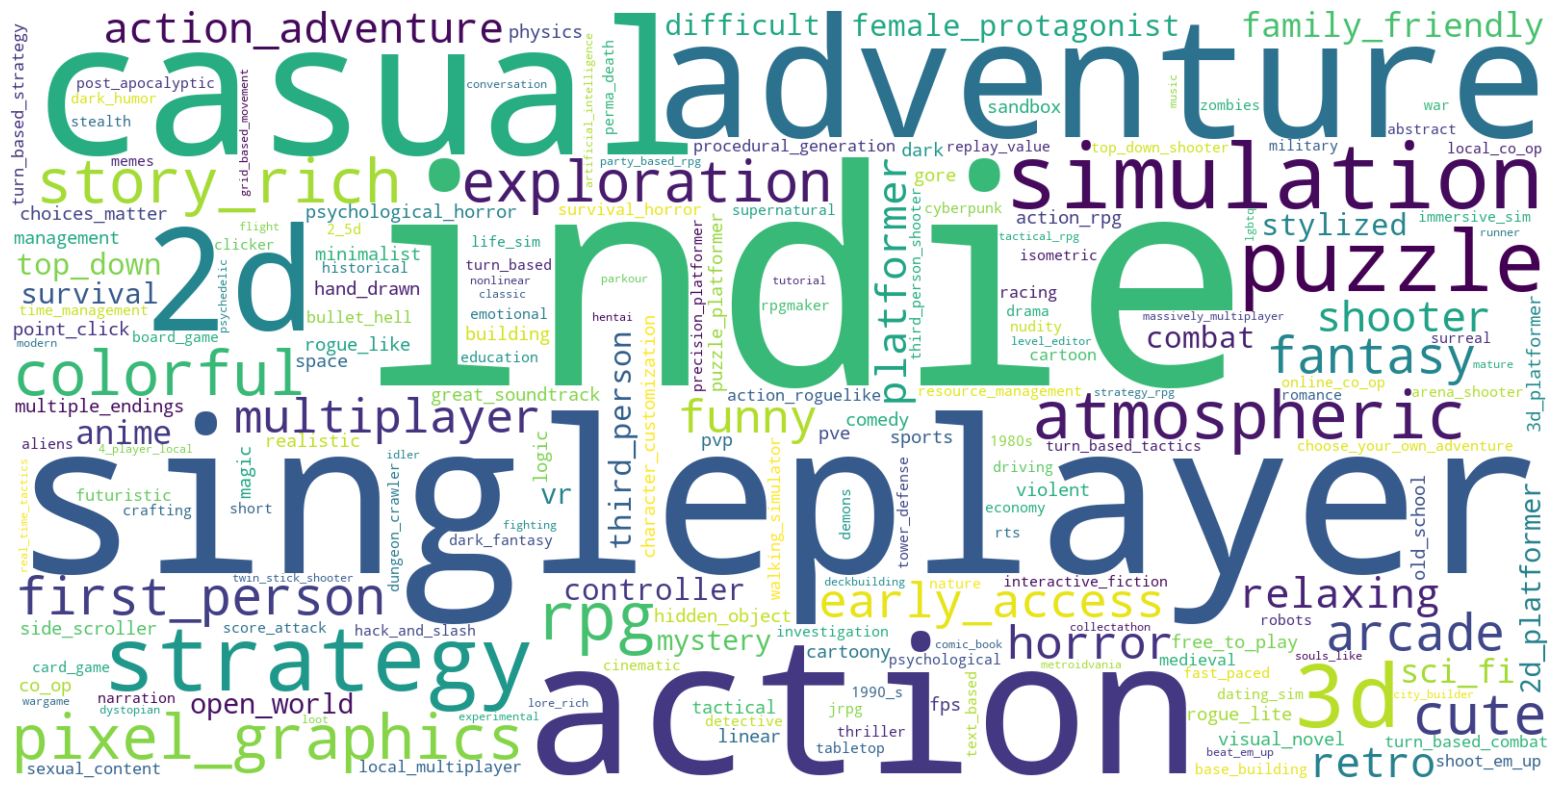

In [6]:
# Count only how often each tag key appears across rows
tag_counter = Counter()

# 'tags' column is a string representation of a dictionary
# Parse the 'tags' column and count the frequency of each tag key
for item in df["tags"]:
    tags_dict = literal_eval(item) if isinstance(item, str) else item
    if isinstance(tags_dict, dict):
        tag_counter.update(tags_dict.keys())  # count keys, not values

# Wordcloud
wc = WordCloud(width=1600, height=800, background_color="white")
wc.generate_from_frequencies(tag_counter)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()

### Game Graveyard
There are a lot of games with 0 *reviews*, 0 *playtime*, and 0 *peak_ccu* present in the dataset. These are the games that no one has ever played. (1 or 2) out of 3  fields have can have 0-value, they could be an error in the dataset, but all three have 0-values is less probabile so. <br>
The area chart shows the trend of number of games published in each year, while highlighting the number of "dead games". Both show an increasing trend over the year.<br><br>

This signals the increasing size of the gaming market, but also tell us that with the releases of new games, more and more competitions fall out of the attention.

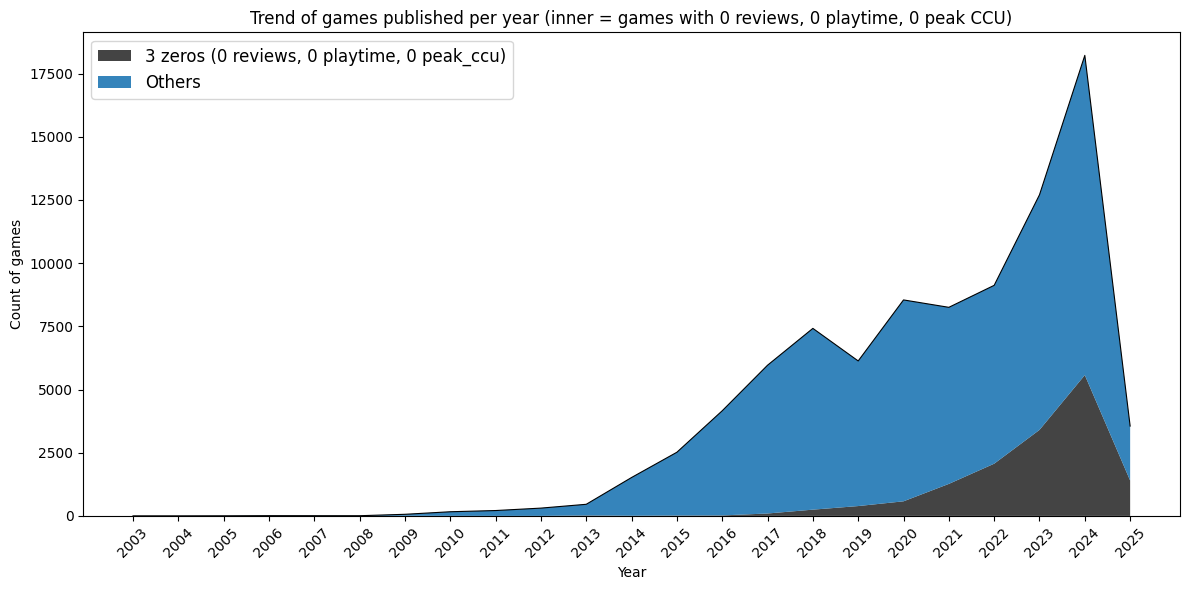

In [7]:
# Sort df by year and reset index
total_by_year = df.groupby("year").size().sort_index()

# Identify games with 0 reviews, 0 playtime, and 0 peak CCU
three_zeros = df[
    (df["num_reviews"] == 0) & (df["avg_playtime"] == 0) & (df["peak_ccu"] == 0)
].copy()

# Count how many of these "3 zeros" games were published each year
zero_by_year = (
    three_zeros.groupby("year").size().reindex(total_by_year.index, fill_value=0)
)

# Calculate the count of "other" games (not "3 zeros") by year
others_by_year = total_by_year - zero_by_year

years = total_by_year.index.astype(int)

plt.figure(figsize=(12, 6))
plt.stackplot(
    years,
    zero_by_year.values,
    others_by_year.values,
    labels=["3 zeros (0 reviews, 0 playtime, 0 peak_ccu)", "Others"],
    colors=["#2f2f2f", "#1f77b4"],
    alpha=0.9,
)

# outline/top line to emphasize the "others" region
plt.plot(years, zero_by_year.values + others_by_year.values, color="black", lw=0.8)
plt.xlabel("Year")
plt.ylabel("Count of games")
plt.title(
    "Trend of games published per year (inner = games with 0 reviews, 0 playtime, 0 peak CCU)"
)

# show all year ticks on x-axis
plt.xticks(years, rotation=45)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

#### How probable is a game destined to 'die'?
The number of dead games increases every year in absolute numbers, but, as we can see from the area chart, starting from 2013, the number of released games each year increase steadly and in 2023 with a sudden jump. This makes us wonder how many games didn't get any attention.<br>
The line chart plots the the percentage of dead games with respect of each year's games releases.<br><br>

As the result, this number actually increases with each passing year, the market was less saturated, maybe not all games get the same attention, but almost all of them had some visibility. In 2024, the number is around 35%, meaning that 1 ou of 3 games is overlooked by everyone and die sliently. This shows the probability of game death increases as growth of the gaming market, signling a possible industry saturation.

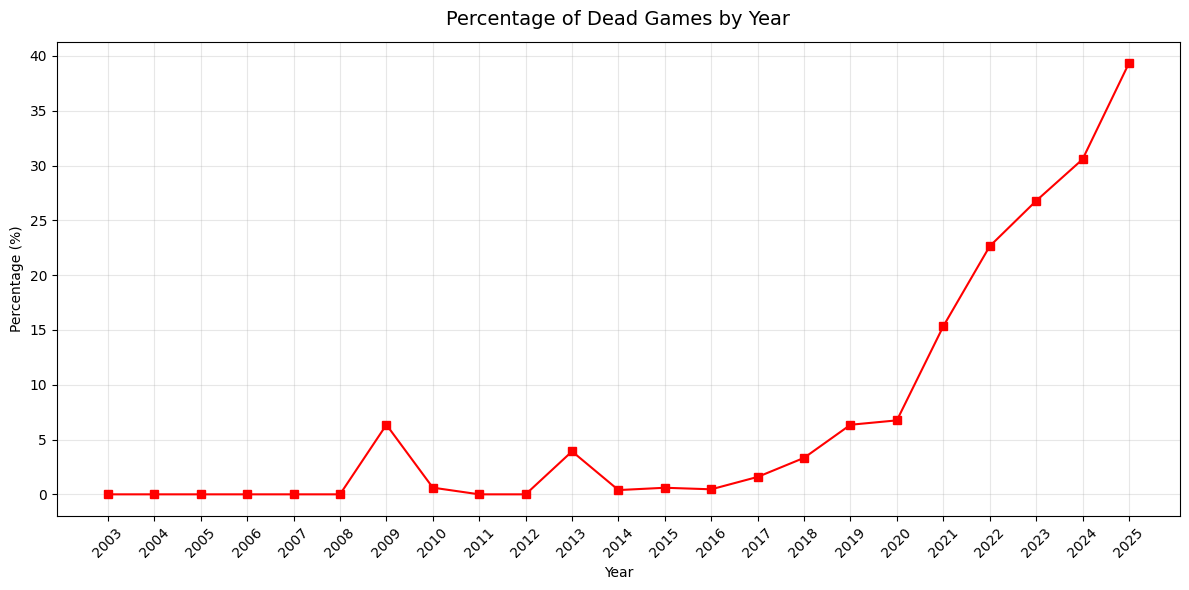

In [8]:
# Calculate the percentage of "3 zeros" games out of total games for each year
pct_death_by_year = (zero_by_year / total_by_year * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(pct_death_by_year.index, pct_death_by_year.values, marker='s', color='red', label='Percentage of Dead Games')
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.set_title('Percentage of Dead Games by Year', fontsize=14, pad=12)
ax.grid(alpha=0.3)

plt.xticks(pct_death_by_year.index, rotation=45)
plt.tight_layout()
plt.show()

#### Price influence
The *hypothesis* behind the dead game is that the **game price** has something to do with a game being "dead", higher the price means bigger the investment.<br><br>

The resulting bar chart that groups the dead games into categories, showing that the price has little to do with the game popularity, since majority of the dead games are free-to-play or under 5 euros. In theory, these games should attract a large gamer base, thanks to the low economic commitment, but the reality is quite the opposite. 

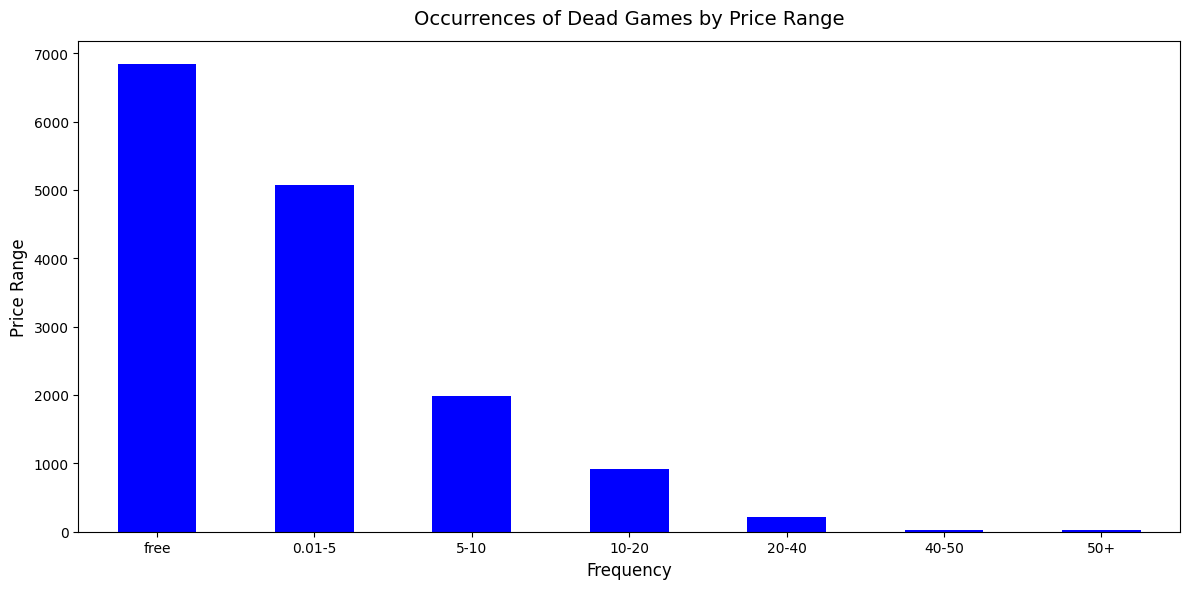

In [9]:
# Set aside the price column for the "3 zeros" games
price_zeros = three_zeros['full_price']

# Define bins and labels
bins = [0.0, 0.01, 5, 10, 20, 40, 50, float('inf')]
labels = ['free', '0.01-5', '5-10', '10-20', '20-40', '40-50', '50+']

# Create a series with price values and bin them
price_binned = pd.cut(price_zeros.values, bins=bins, labels=labels, right=False)
price_binned_counts = price_binned.value_counts().sort_index()

ax = price_binned_counts.plot(
    kind='bar',
    figsize=(12, 6),
    color='blue'
)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_ylabel('Price Range', fontsize=12)
ax.set_title('Occurrences of Dead Games by Price Range', fontsize=14, pad=12)
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()

#### Game curation, measured by *achievements*
Another hypothesis is that *dead games* are not quality-wise complete, that the **developers did not care for the product**. One subtle indicator is the game's number of achievements (or trophys). Throphys are a mechanism to encourage players to engage in the games, rewarding for playing and exploring the game mechanics, as a way of showing the dedications that the developers put into the games. However, this is not an absolute metric for quality game assessment.<br><br>

The resulting stacked bar chart shows that the hypothesis is not necessarily true, games with lower number of achievements are not by default less cared for, at least not statistically so. 

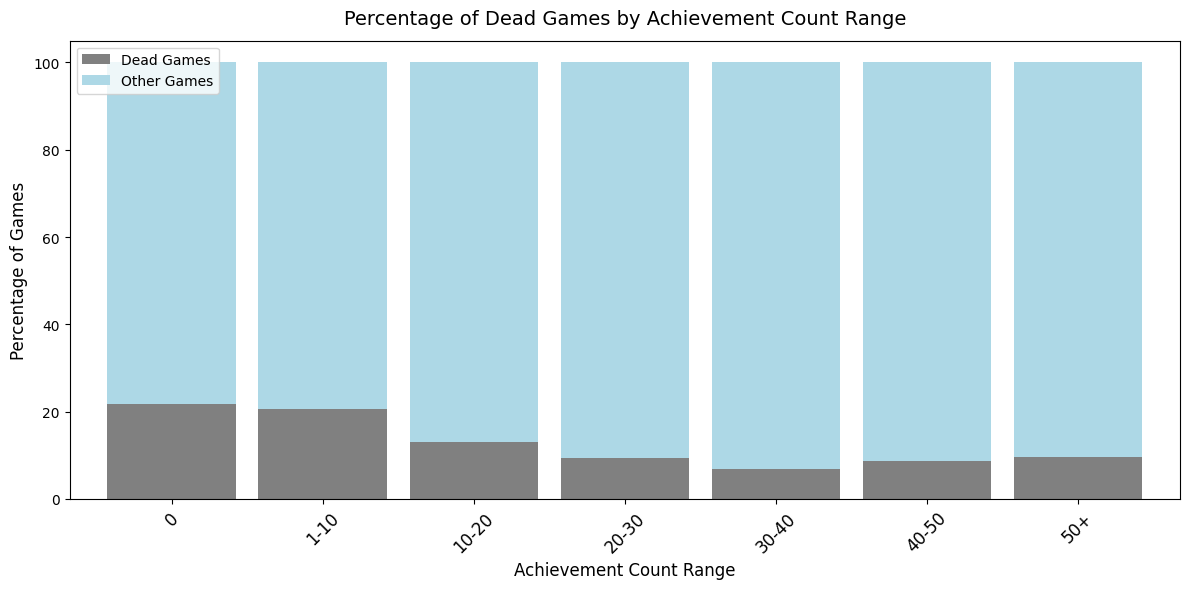

In [10]:
# Analyze the distribution of achievement counts for "3 zeros" games vs all games
trophy_zeros = three_zeros['achievements']
trophy_all = df['achievements'].copy()

bins = [0, 1, 10, 20, 30, 40, 50, float('inf')]
labels = ['0', '1-10', '10-20', '20-30', '30-40', '40-50', '50+']

# Bin the achievement counts for both the zero group and the entire dataset
trophy_binned_zeros = pd.cut(trophy_zeros.values, bins=bins, labels=labels, right=False)
trophy_binned_all = pd.cut(trophy_all.values, bins=bins, labels=labels, right=False)

trophy_binned_zeros_counts = trophy_binned_zeros.value_counts().sort_index()
trophy_binned_all_counts = trophy_binned_all.value_counts().sort_index()

pct_zeros = (trophy_binned_zeros_counts / trophy_binned_all_counts) * 100
pct_others = 100 - pct_zeros

plot = pd.DataFrame({
    'Dead Games': pct_zeros,
    'Other Games': pct_others
})

ax = plot.plot(
    kind = 'bar',
    stacked = True,
    figsize = (12, 6),
    color = ['grey', 'lightblue'],
    width=0.85
)

ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel('Achievement Count Range', fontsize=12)
ax.set_ylabel('Percentage of Games', fontsize=12)
ax.set_title('Percentage of Dead Games by Achievement Count Range', fontsize=14, pad=12)
ax.set_xticklabels(labels, rotation=45, fontsize=12)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

#### Genre death
Could the **game genres** have anything to do with being "dead"? It is possible that the common player preferences have shifted. So the *new games* of less popular genres get overlooked.<br><br>

However, the horizontal bar chart did not confirm this hypothesis either, by showing the most frequently appeared genres among dead games, we noticed that there aren't any genre stands out, rather the distribution is almost equal among genres.

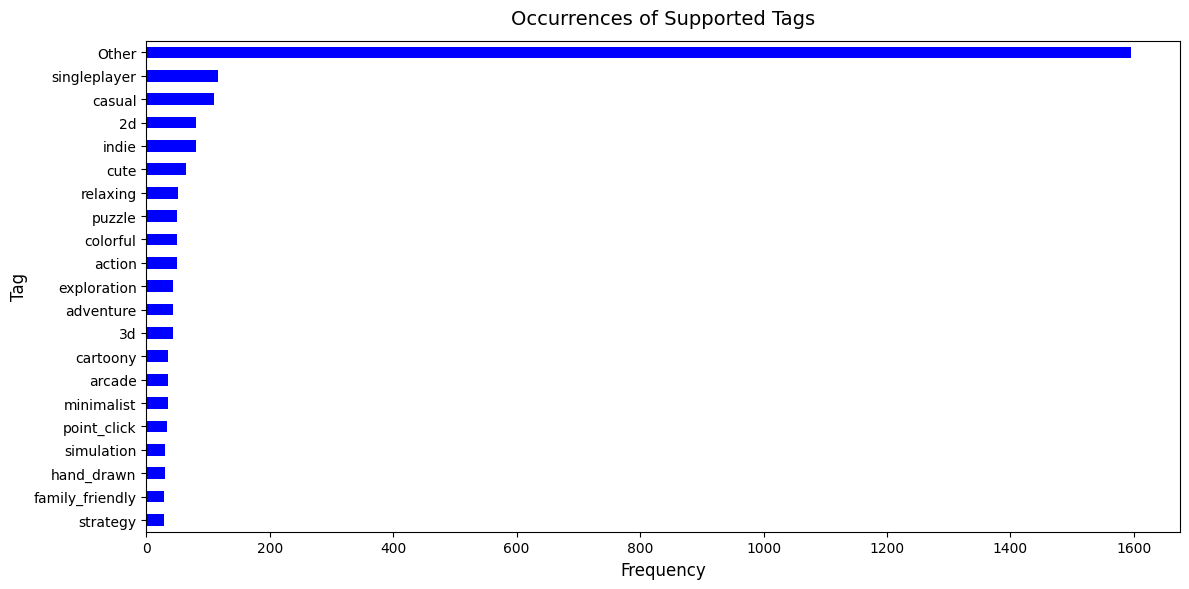

In [11]:
# Count only how often each tag key appears across entries
tag_counter = Counter()

# Filter the 'tags' column, a dictionary on the three_zeros subset
for item in three_zeros['tags']:
    tags_dict = literal_eval(item) if isinstance(item, str) else item
    if isinstance(tags_dict, dict):
        tag_counter.update(tags_dict.keys())  # count keys, not values

tag_counter = pd.Series(tag_counter).sort_values(ascending=False)

# Limit to top 20 tags + "Other" category
max_bars = 20
if len(tag_counter) > max_bars:
    top = tag_counter.head(max_bars).copy()
    top['Other'] = tag_counter.iloc[max_bars:].sum()
else:
    top = tag_counter.copy()

# Create horizontal bar chart
ax = top.sort_values().plot(
    kind='barh',
    figsize=(12, max(6, 0.25 * len(top))),
    color='blue'
)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_ylabel('Tag', fontsize=12)
ax.set_title('Occurrences of Supported Tags', fontsize=14, pad=12)

plt.tight_layout()
plt.show()

#### Final considearion
From the available data, the reason behind the continue rise of dead games is inconclusive, it is difficult to statistically prove the trend.<br>
However, a possible explaination could be that most of these games are abbandoned project left unfinished, semi-finised, or testing project. Without a price as a possible indicator, they *scream* low-budget and low-quality with no investors behind the project, they do to encourage players to try them out

### Indie game paradox
How does the ease of publishing low-budget games, so called, indie games change the gaming industry?<br>
The area chart shows that the releases of indie games are steady over the year. But at a first sight, it does not seem to disrupt the gaming market with their presence. It showed a steady increse until 2018 when the number saturated, but, they do still represent a big portion of the market, even in 2024.<br><br>

Further analysis are needed to confirm the non-disruption

In [12]:
# Helper function to check if a tag dictionary contains the "indie" tag
def has_indie(t):
    if isinstance(t, str):
        try:
            d = literal_eval(t)
        except Exception:
            return False
    else:
        d = t
    return isinstance(d, dict) and ("indie" in d)

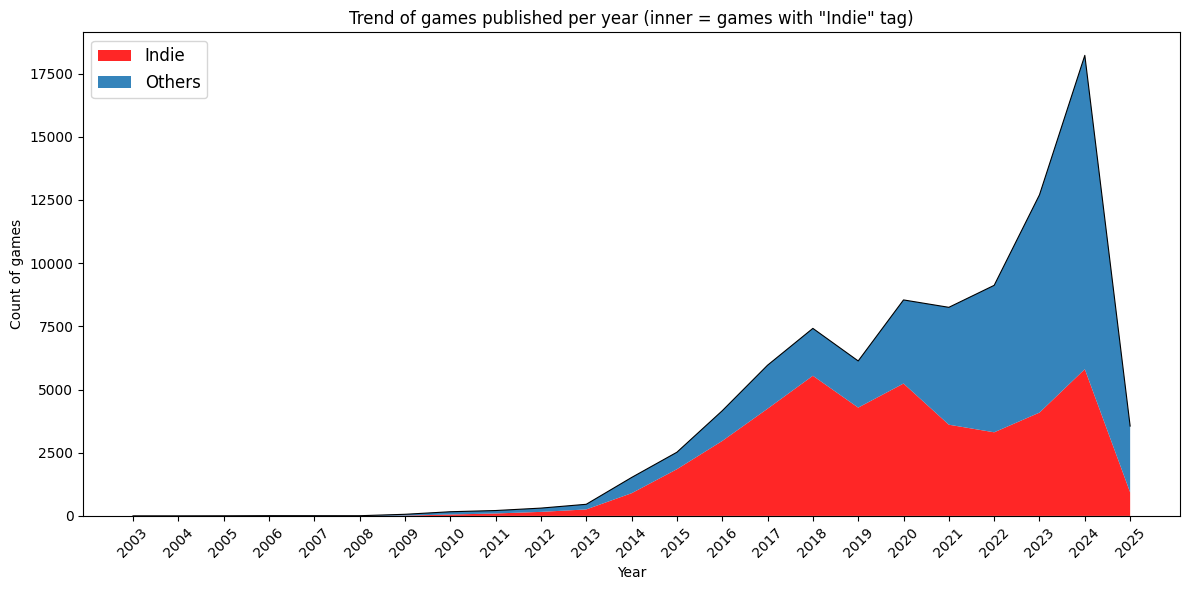

In [13]:
# Count games with 'indie' tag per year
indie_mask = df["tags"].copy().apply(has_indie)
indie_by_year = (
    df[indie_mask].copy().groupby("year").size().reindex(total_by_year.index, fill_value=0)
)

# total_by_year has been defined in the previous cell
others_by_year = total_by_year - indie_by_year

plt.figure(figsize=(12, 6))
plt.stackplot(
    years,
    indie_by_year.values,
    others_by_year.values,
    labels=["Indie", "Others"],
    colors=["#ff0e0e", "#1f77b4"],
    alpha=0.9,
)

# outline/top line to emphasize the "others" region
plt.plot(years, indie_by_year.values + others_by_year.values, color="black", lw=0.8)
plt.xlabel("Year")
plt.ylabel("Count of games")
plt.title('Trend of games published per year (inner = games with "Indie" tag)')
plt.xticks(years, rotation=45)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

#### Indie genres are really overlooked?
Circling back to the 'dead games', we want to know how many of these indie games really ended up in the 'graveyard', because the constant growth of the gaming merket.<br>
The resulting stacked bar chart depicts the size of gaming market by each year while highlighting the portion of the dead/alive indie games.<br><br>

The result shows that the dead indie games occupy a very small portion of the game database, highlighted in color green, however, because the small in number, its portion is barely visible on the graph. Thus, contradicting the hypothesis of indie games being overlooked

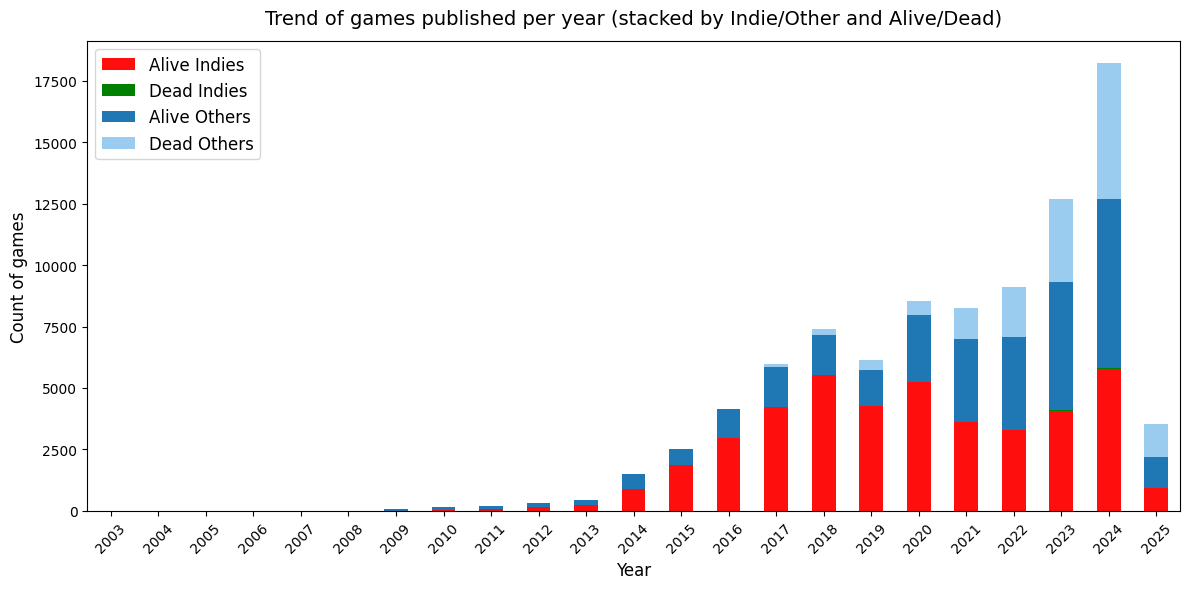

In [14]:
# Count dead games with 'indie' tag per year
zero_indie_mask = three_zeros[three_zeros["tags"].apply(has_indie)]
zero_indie_by_year = zero_indie_mask.groupby("year").size().reindex(total_by_year.index, fill_value=0)

alive_indie_by_year = indie_by_year - zero_indie_by_year
zero_others_by_year = zero_by_year - zero_indie_by_year
alive_others_by_year = others_by_year - zero_others_by_year

plot_indies = pd.DataFrame({
    "Alive Indies": alive_indie_by_year,
    "Dead Indies": zero_indie_by_year,
    "Alive Others": alive_others_by_year,
    "Dead Others": zero_others_by_year,
})

ax = plot_indies.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["#ff0e0e", "green", "#1f77b4", "#99ccee"],
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Count of games", fontsize=12)
ax.set_title("Trend of games published per year (stacked by Indie/Other and Alive/Dead)", fontsize=14, pad=12)
ax.set_xticklabels(years, rotation=45)
ax.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

#### Game attentions
*How does the continuous growth of gaming market size affects the game visibility, and how does the indie genre contributes to it?*<br>
A useful indicator to explore and answer this question is the **median** number of reviews. Reviews represent the number of feedbacks from the players, it can be either positive or negative, and the steam ensures that an user can leave a review only and only if the user has played the game. Unlike *average_playtime*, whose value is calculated with a certain frequency, *num_reviews*'s value is cumulative, and is less likely to have an erronous value when collecting data<br>
The line charts show the yearly trend of median and mean number of reviews of both indie games only and all games. <br><br>

The results show:
1. the attention each game receives gets dilluted with each passing year as shown by the mean reviews of yearly trend of all games
2. majority of games receive very little attention, this is very evident when analyzing the median values, where after 2006, the median reviews of both indie and all-games are so little they seem to reach to zero compared with the 2006's value
3. the comparison between mean and median tells us that only a handful of games receive the most of attention. Take as example the year 2006, where the median value of all games are seemingly zero, but its indie game counter part reaches almost 600000 reviews, and the same year, its mean is ~120000, higher only year with the higher value is 2007.
<br><br>

These findings suggest that the attention distribution of games is highly skewed, concentrating on only a handlful of game.

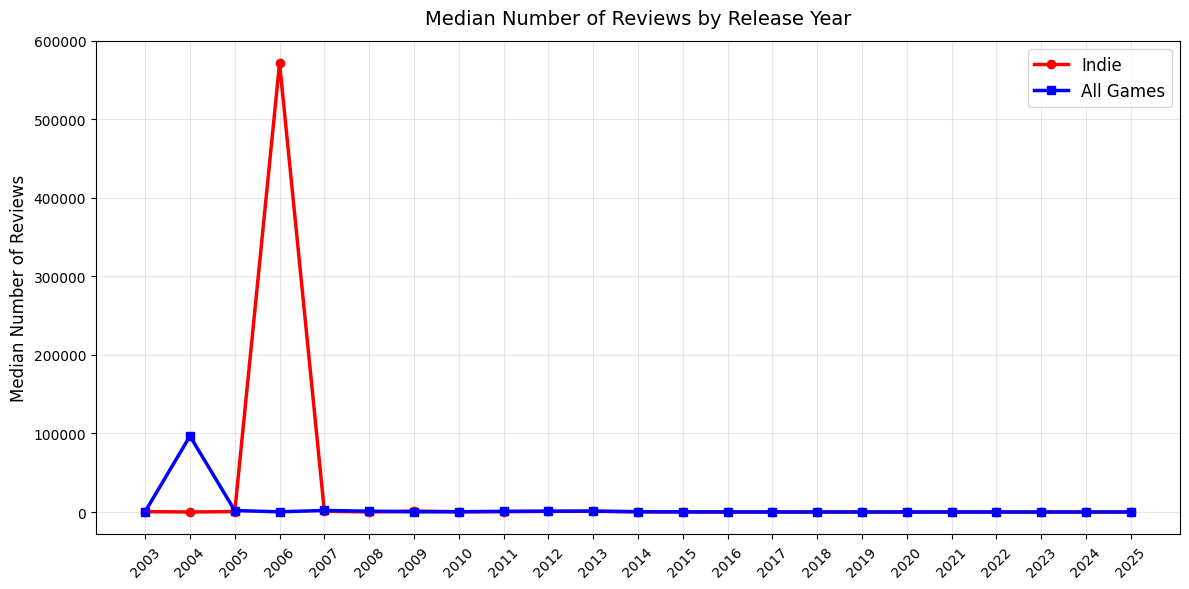

In [15]:
indie_mask = df[df['tags'].copy().apply(has_indie)]
indie_median_by_year = indie_mask.groupby('year')['num_reviews'].median().reindex(total_by_year.index, fill_value=0)
all_median_by_year = df.copy().groupby('year')['num_reviews'].median().reindex(total_by_year.index, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

# Indie
ax.plot(
    indie_median_by_year.index,
    indie_median_by_year.values,
    label='Indie',
    marker='o',
    color='red',
    linewidth=2.5
)

# Non-Indie
ax.plot(
    all_median_by_year.index,
    all_median_by_year.values,
    label='All Games',
    marker='s',
    color='blue',
    linewidth=2.5
)

ax.set_xticks(years)
ax.set_ylabel('Median Number of Reviews', fontsize=12)
ax.set_title('Median Number of Reviews by Release Year', fontsize=14, pad=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Seeing the extreme values present in 2004 and 2006, thanks to which, the rest of data seem to be zeros. A new line chart showing the median values excluding the extreme values is plotted.<br><br>

This new line chart further confirms the hypothesis that as the market saturates, the attention each game receives dillutes more and more, not just the indie genre.

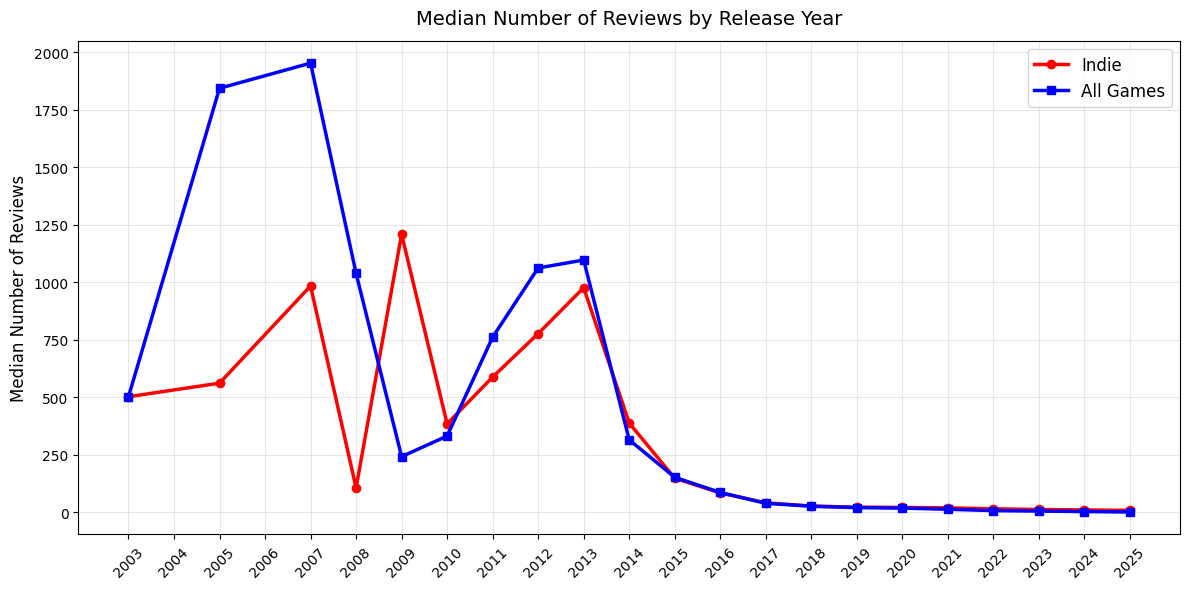

In [16]:
indie_median_by_year = indie_median_by_year.drop(index=[2004, 2006])
all_median_by_year = all_median_by_year.drop(index=[2004, 2006])
fig, ax = plt.subplots(figsize=(12, 6))

# Indie
ax.plot(
    indie_median_by_year.index,
    indie_median_by_year.values,
    label='Indie',
    marker='o',
    color='red',
    linewidth=2.5
)

# Non-Indie
ax.plot(
    all_median_by_year.index,
    all_median_by_year.values,
    label='All Games',
    marker='s',
    color='blue',
    linewidth=2.5
)

ax.set_xticks(years)
ax.set_ylabel('Median Number of Reviews', fontsize=12)
ax.set_title('Median Number of Reviews by Release Year', fontsize=14, pad=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

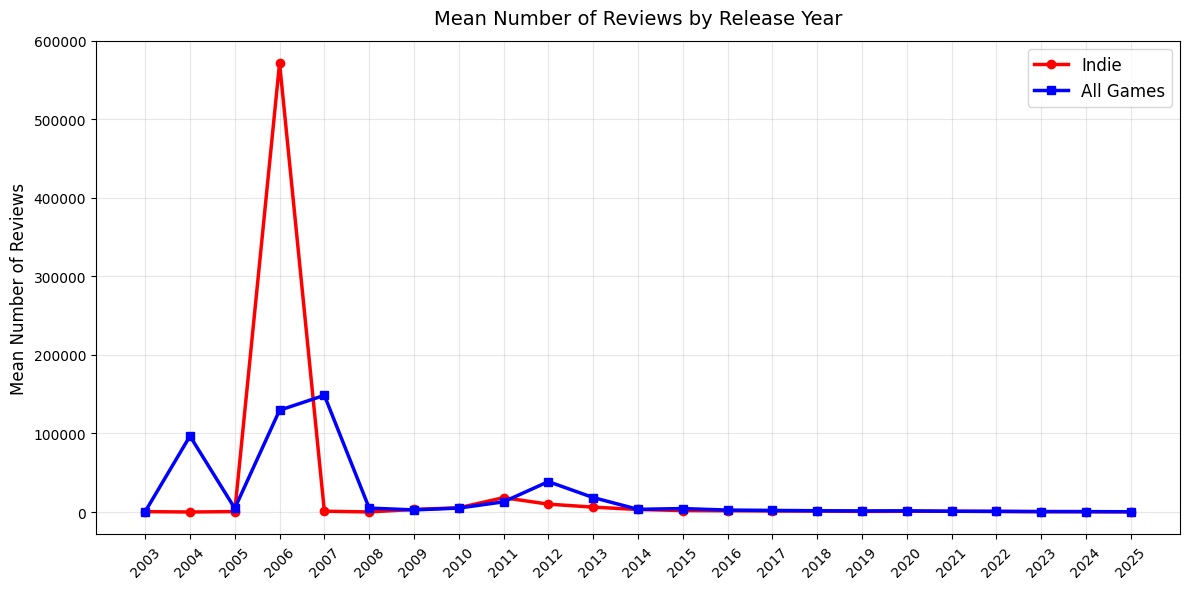

In [17]:
indie_mean_by_year = indie_mask.groupby('year')['num_reviews'].mean().reindex(total_by_year.index, fill_value=0)
all_mean_by_year = df.copy().groupby('year')['num_reviews'].mean().reindex(total_by_year.index, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

# Indie
ax.plot(
    indie_mean_by_year.index,
    indie_mean_by_year.values,
    label='Indie',
    marker='o',
    color='red',
    linewidth=2.5
)

# Non-Indie
ax.plot(
    all_mean_by_year.index,
    all_mean_by_year.values,
    label='All Games',
    marker='s',
    color='blue',
    linewidth=2.5
)

ax.set_xticks(years)
ax.set_ylabel('Mean Number of Reviews', fontsize=12)
ax.set_title('Mean Number of Reviews by Release Year', fontsize=14, pad=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

While the following line chart is mostly meaningless, because the presence of extreme values in the dataset. It is still refreshing to see how they can alter the graphics completely

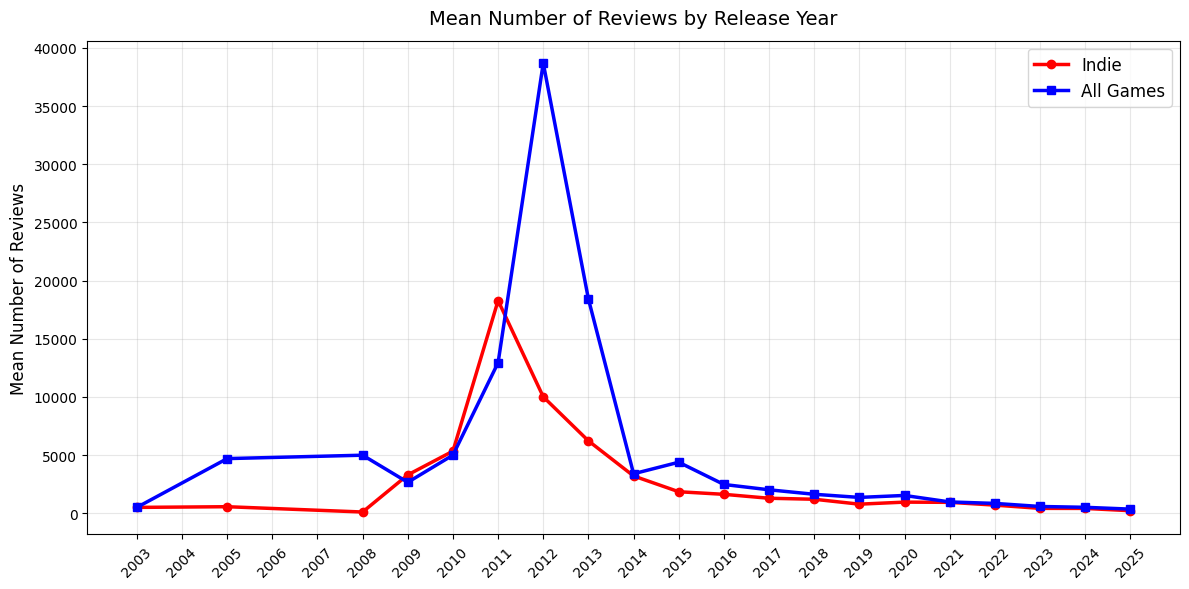

In [18]:
indie_mean_by_year = indie_mean_by_year.drop(index=[2004, 2006, 2007])
all_mean_by_year = all_mean_by_year.drop(index=[2004, 2006, 2007])

fig, ax = plt.subplots(figsize=(12, 6))

# Indie
ax.plot(
    indie_mean_by_year.index,
    indie_mean_by_year.values,
    label='Indie',
    marker='o',
    color='red',
    linewidth=2.5
)

# Non-Indie
ax.plot(
    all_mean_by_year.index,
    all_mean_by_year.values,
    label='All Games',
    marker='s',
    color='blue',
    linewidth=2.5
)

ax.set_xticks(years)
ax.set_ylabel('Mean Number of Reviews', fontsize=12)
ax.set_title('Mean Number of Reviews by Release Year', fontsize=14, pad=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Case study: 2006
We want to know what makes the 2006 such a particular year in the gaming industry, if it is the boom of the indie genre, or some particular games?<br>
The bar chart shows simply the distribution of num_reviews_total in all the 2006's games<br><br>

The result to the extreme particularity of 2006's value is given by 2 factors:
1. there are only 9 games releases in 2006, 2 of which has tag 'indie'
2. one game, "garry's mode" has an astonishing ~1200000 reviews.
<br><br>

The plots show that 2006 is an exception not because it was a great year for indie genre, but because one blockbuster that influenced the data distribution

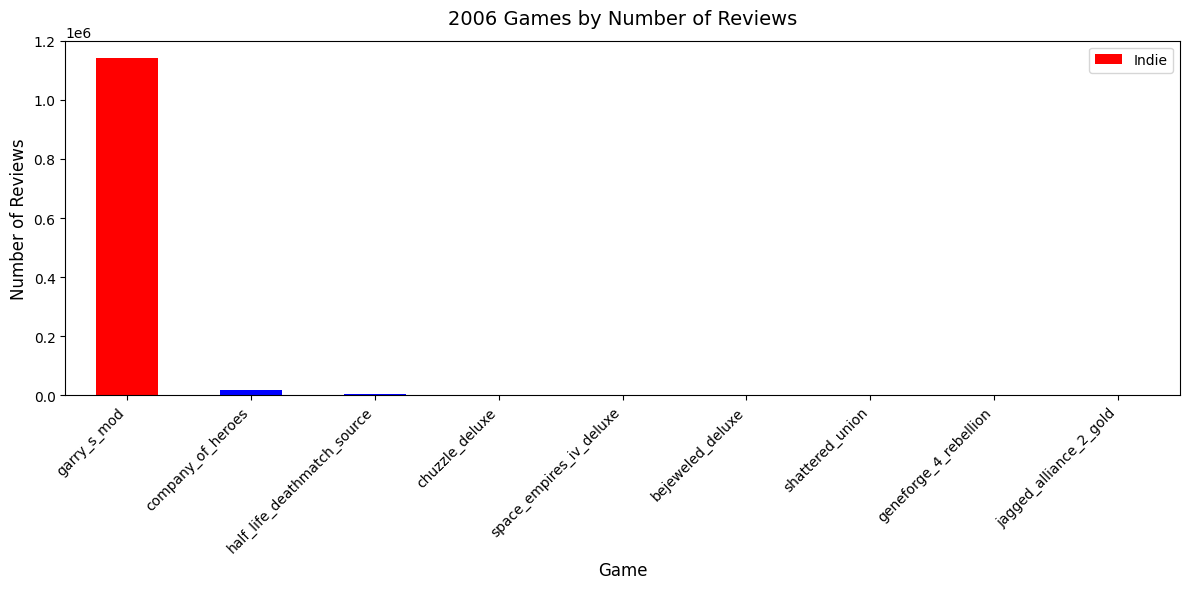

In [19]:
# Get the games released in 2006 and identify which of them are indie games
games_2006 = df[df['year'] == 2006].copy()
indie_2006 = games_2006[games_2006['id'].isin(indie_mask['id'])]
games_2006 = games_2006.sort_values('num_reviews', ascending=False)

ax = games_2006.plot(
    x='name',
    y='num_reviews',
    kind='bar',
    figsize=(12, 6),
    color=['red' if id in indie_2006['id'].values else 'blue' for id in games_2006['id']],
)

ax.set_xlabel('Game', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_title(f'2006 Games by Number of Reviews', fontsize=14, pad=12)
ax.set_xticklabels(labels=games_2006['name'], rotation=45, ha='right')
ax.legend(['Indie', 'Other'], loc='upper right')
plt.tight_layout()
plt.show()

#### How much visibility does indie genre have?
We know would like to know if the indie genre really didn't take off in the gaming market, and how much visibility does it really have. We compare the total number of reviews of indie genre against the total number of reviews each year.<br>
The stacked bar chart shows exactly the portion of indie genre visibility against the total

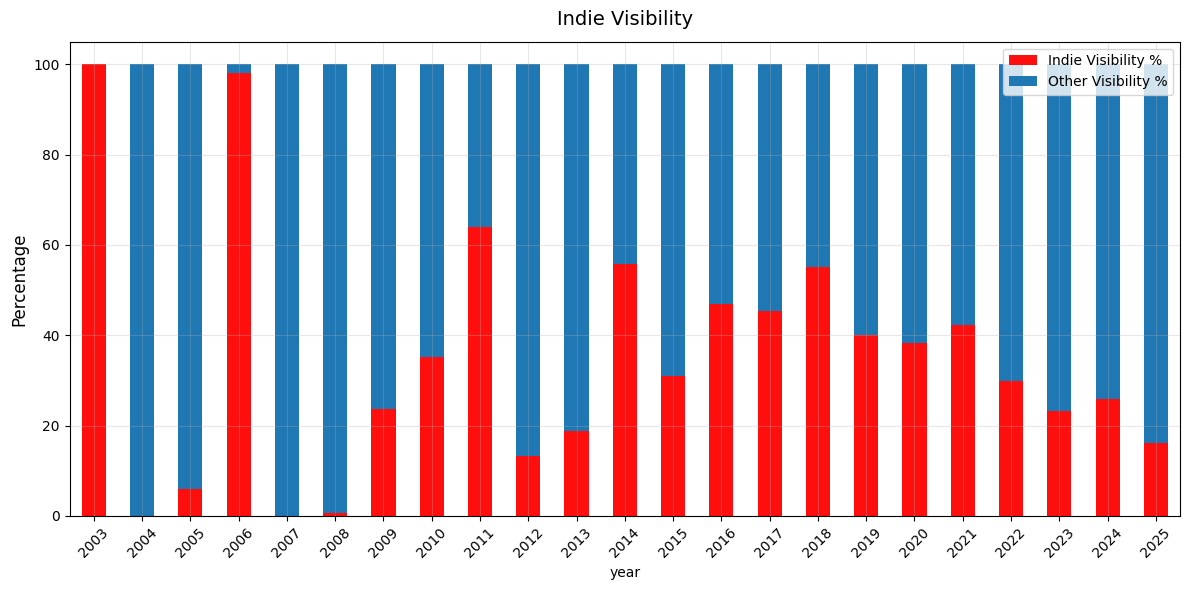

In [20]:
indie_visibility_year = indie_mask.groupby("year")["num_reviews"].sum()
# Add 2004 with 0 visibility to align with total_by_year index
indie_visibility_year.loc[2004] = 0 
all_visibility_year = df.copy().groupby("year")["num_reviews"].sum()

# Calculate the percentage of indie visibility out of total visibility for each year
pct_indie_visibility = (indie_visibility_year / all_visibility_year) * 100
pct_other_visibility = 100 - pct_indie_visibility

plot_pct_indie_visibility = pd.DataFrame({
        "Indie Visibility %": pct_indie_visibility,
        "Other Visibility %": pct_other_visibility,
})

ax = plot_pct_indie_visibility.plot(kind="bar", stacked=True, figsize=(12, 6), color=["#ff0e0e", "#1f77b4"])
ax.set_ylabel("Percentage", fontsize=12)
ax.set_title("Indie Visibility", fontsize=14, pad=12)
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Does the indie genre visibility grow the same speed as the growth of the gaming market?
To analyze the trend of the indie genre, a multi-line plot is traced showing the percentage of new games released in each year(in blue) and the percentage of increase in the indie visibility.<br>
To analyze better the trend, we focus only on the data from 2009 and onward. If 2006 data in included, the plot would be disrupted by the irregularity, the same goes for 2008, which shows a 175 times increase in indie visibility.<br><br>

The result shows that while the indie visibility suffered a steep downfall from 2011 to 2012, it has since maintained a almost smooth change along side the increase in the number of games released each year. 

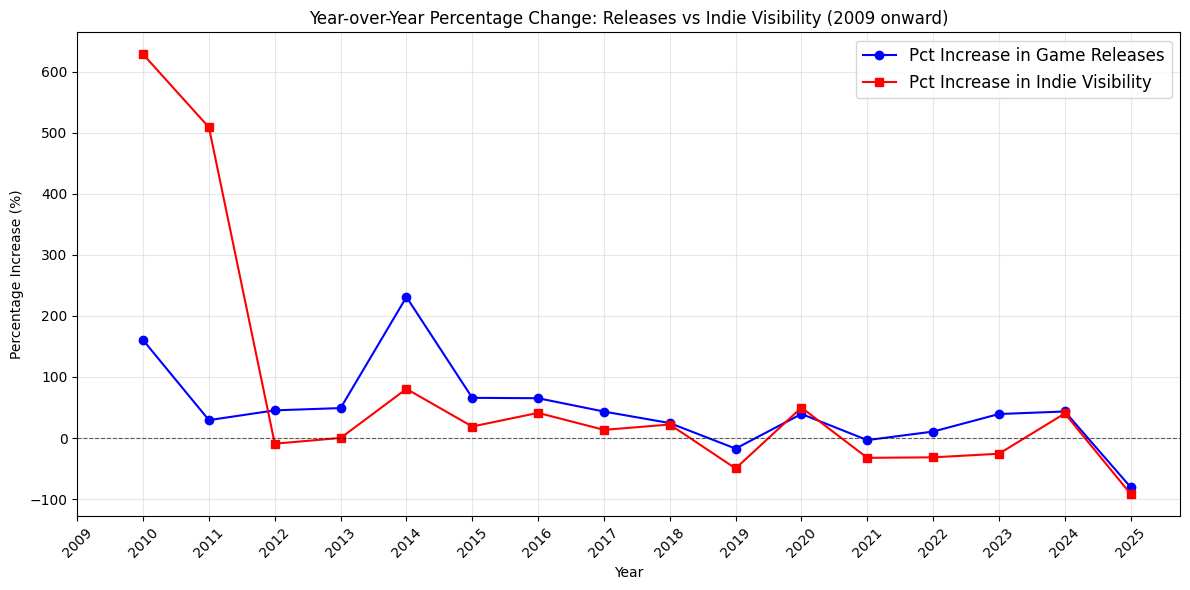

In [21]:
# Align indices from 2009 onward
total = total_by_year.loc[2009:].copy()
indie_vis = indie_visibility_year.reindex(total.index, fill_value=0)

# Year-over-year percent change
total_pct = total.pct_change() * 100
indie_pct = indie_vis.pct_change() * 100

# Remove infinite values (division by zero cases)
total_pct.replace([np.inf, -np.inf], np.nan, inplace=True)
indie_pct.replace([np.inf, -np.inf], np.nan, inplace=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(total_pct.index, total_pct.values, marker='o', color='blue', label='Pct Increase in Game Releases')
ax.plot(indie_pct.index, indie_pct.values, marker='s', color='red', label='Pct Increase in Indie Visibility')

ax.set_xlabel('Year')
ax.set_ylabel('Percentage Increase (%)')
ax.set_title('Year-over-Year Percentage Change: Releases vs Indie Visibility (2009 onward)')
# Plot a horizontal line at y=0 to indicate 0% change
ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.6)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.xticks(total.index, rotation=45)
plt.tight_layout()
plt.show()

#### Final consideration
The indie genre is mainly characterized by the low-budget product, and thus requires lower economic commitment from the user's perspective. Surely the huge success of the 2006' indie game "garry's mod" has set a trend in the industry, followed by other hits like "terraria" or "stardew valley", which are among the most reviewed games of all time. <br>
The genre has seen a steady increase in the number of new games released each year, its visibility has seen drastic changes in the first decade of 2000, but has since secured its place in the vast gaming market, despite the continue increase in the total number of games released each year.<br>

### Winner takes all?
At this point, we observe a subtle fact, that only a few games stand out in the gaming market holding the majority of player's attention. Which is what happened in year 2006.<br>
Hypothesis: *A handful of games hold all the attentions of the players, while the rest receives little to none*.<br>
Lorenz Curve seems to be the most natural visualization tool to show the distribution of 'wealth' among the games and Gini coefficient as a support to show how the 'wealth' is inequally distributed (higher the gini coeff., higher the inequality).<br><br>

The resulting graph shows Lorenz curve of *num_reviews*, *avg_playtime*, and *peak_ccu*, all three attributes can be seen as a measure of wealth in the context of gaming industry, in the absence of sales data.<br>
They confirm the hypothesis that a small percentage of games hold the most of attentions: 
1. number of reviews is slightly more distributed with rispect of other two attributes, but still highly inequal.
2. average playtime and ccu's curve are more concentrated around 10% of games. Around 90% of games share almost 0% (if not precisely zero) wealth. 

In [22]:
# A brief summary on the statistical distribution of the "wealth" features (reviews, playtime, peak CCU)
wealth = df[['num_reviews', 'avg_playtime', 'peak_ccu']].copy()
for col in wealth.columns:
    print(f"{col}: mean = {wealth[col].mean():.2f}, median = {wealth[col].median():.2f}")

num_reviews: mean = 1481.92, median = 13.00
avg_playtime: mean = 115.25, median = 0.00
peak_ccu: mean = 1226.84, median = 0.00


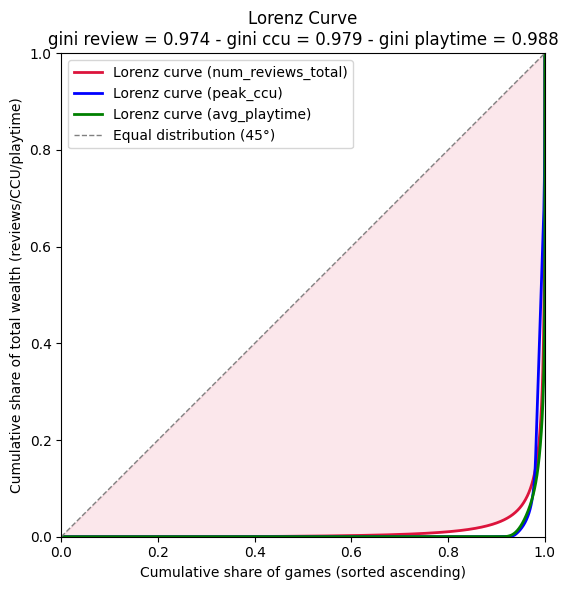

In [23]:
# Lorenz curve and Gini coefficient for 'num_reviews' 
# # Gini coefficient: 1 - 2 * area under the Lorenz curve
val_reviews = np.sort(df['num_reviews'].values)  # sort values in ascending order
n = len(val_reviews)
cum_vals = np.cumsum(val_reviews)
cum_pct_reviews = cum_vals / cum_vals[-1] # % cumulative of total reviews
cum_pct_games = np.arange(1, n + 1) / n  # % cumulative of games
gini_reviews = 1 - 2 * np.trapezoid(cum_pct_reviews, cum_pct_games)

# Lorenz curves for 'peak_ccu'
val_ccu = np.sort(df['peak_ccu'].values)
cum_val_ccu = np.cumsum(val_ccu)
cum_pct_ccu = cum_val_ccu / cum_val_ccu[-1]
gini_ccu = 1 - 2 * np.trapezoid(cum_pct_ccu, cum_pct_games)

# Lorenz curves for 'avg_playtime'
val_playtime = np.sort(df['avg_playtime'].values)
cum_val_playtime = np.cumsum(val_playtime)
cum_pct_playtime = cum_val_playtime / cum_val_playtime[-1]
gini_playtime = 1 - 2 * np.trapezoid(cum_pct_playtime, cum_pct_games)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(cum_pct_games, cum_pct_reviews, color='crimson', linewidth=2,
        label='Lorenz curve (num_reviews_total)')
ax.plot(cum_pct_games, cum_pct_ccu, color='blue', linewidth=2,
        label='Lorenz curve (peak_ccu)')
ax.plot(cum_pct_games, cum_pct_playtime, color='green', linewidth=2,
        label='Lorenz curve (avg_playtime)')

# Add the 45° line for reference
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1,
        label='Equal distribution (45°)')
ax.fill_between(cum_pct_games, cum_pct_reviews, cum_pct_games,
                 color='crimson', alpha=0.1)

ax.set_xlabel('Cumulative share of games (sorted ascending)')
ax.set_ylabel('Cumulative share of total wealth (reviews/CCU/playtime)')
ax.set_title(f'Lorenz Curve\ngini review = {gini_reviews:.3f} - gini ccu = {gini_ccu:.3f} - gini playtime = {gini_playtime:.3f}')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

#### Who are these most popular games
We would like to put a name to the label.<br>
The horizontal bar chart shows the top 20 games with the most number of reviews, among them, popular titles like "counter strike 2", "dota 2", "grand theft auto", "terraria", "stardew valley" and more.<br>

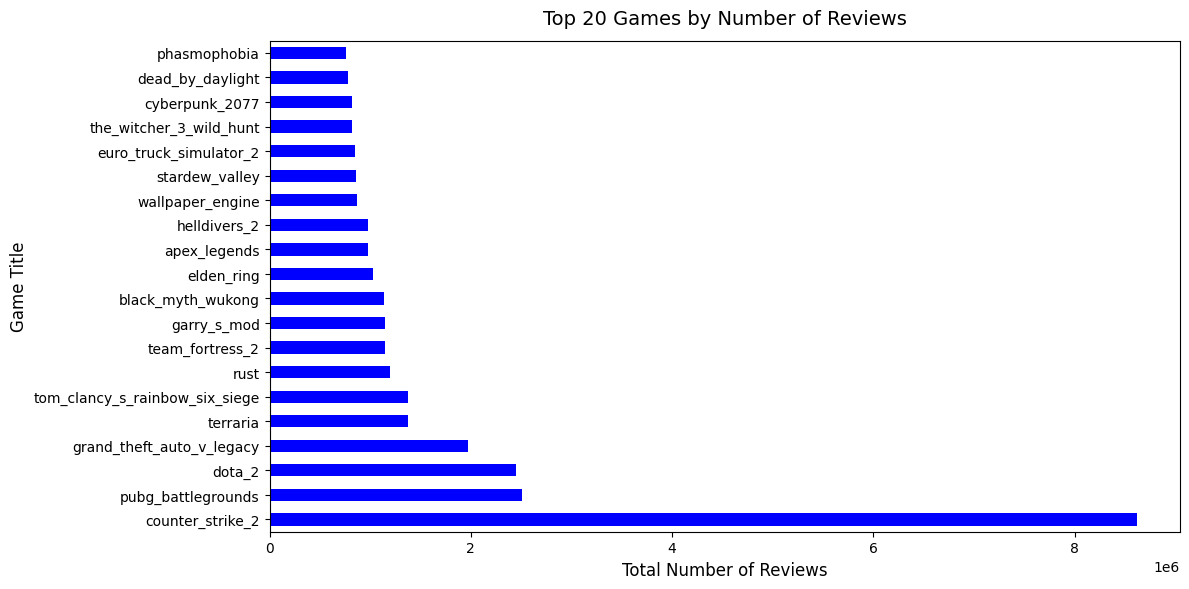

In [24]:
review_rank = df.copy().sort_values('num_reviews', ascending=False).reset_index(drop=True)
top = 20

ax = review_rank.head(top).plot(
    x='name',
    y='num_reviews',
    kind='barh',
    figsize=(12, 6),
    color='blue',
    legend=False
)
ax.set_xlabel('Total Number of Reviews', fontsize=12)
ax.set_ylabel('Game Title', fontsize=12)
ax.set_title(f'Top {top} Games by Number of Reviews', fontsize=14, pad=12)

plt.tight_layout()
plt.show()

#### Winner keeps it all?
Now we know that the few games controls almost all of the attention in the market, but, is this trend a constant? Because the constant growth in the number of released games, one would naturally think that the attention would be distribution more and more equally among games, higher the denominator, smaller the fraction.<br>
The resulting line chart shows the percentage of attention that the *top 1%* of games hold in each year, in terms of number of reviews. And a bar chart to remind the growth in the number of games released.<br><br>

Surprisingly, the top 1% of games keep the most of attention each year, after 2015, share of attention iss in a steady range of 70-80%, if not increasing. This shows that even if the number of competitions grows, the most of player community still prefers a few handful of games.

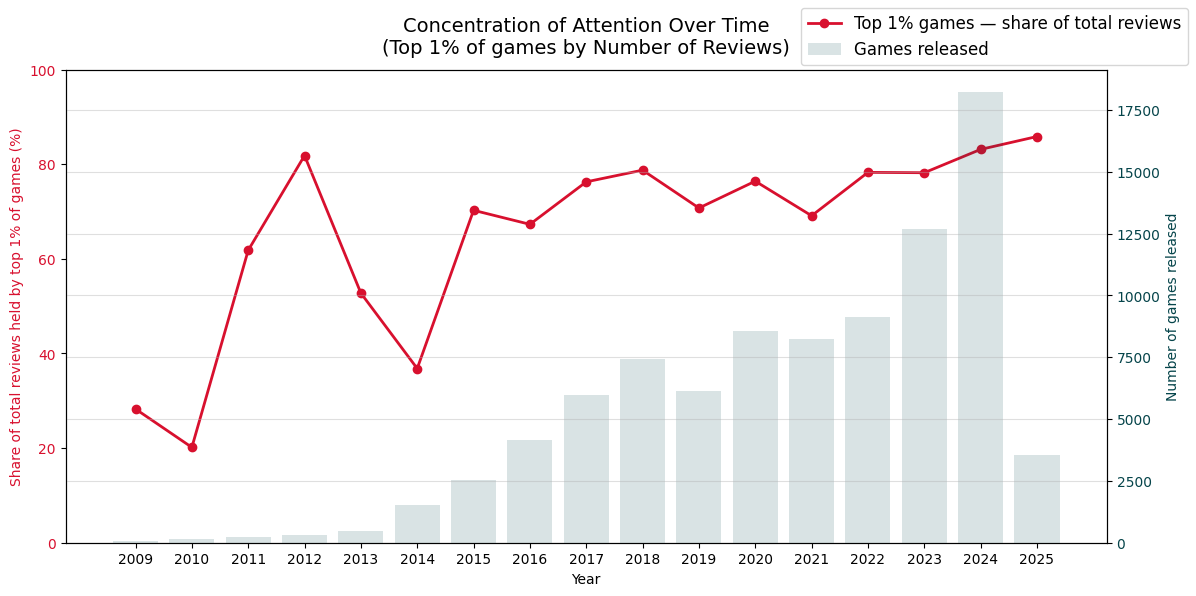

In [25]:
# Compute the share of total reviews held by the top 1% of games for each year
top_pct = 0.01  # top 1%
results = []

for yr in sorted(df['year'].unique()):
    sub = df[df['year'] == yr]['num_reviews'].values
    if len(sub) < 20 or sub.sum() == 0:
        continue  # Filter out years with too few games or no reviews

    sub_sorted = np.sort(sub)[::-1] # sort in descending order
    k = max(1, int(len(sub) * top_pct)) # at least 1 game in top 1%
    share = sub_sorted[:k].sum() / sub_sorted.sum() * 100

    results.append({'year': yr, 'n_games': len(sub), 'top1pct_share': share})

# Convert results to DataFrame for plotting
concentration_df = pd.DataFrame(results)
# Extract years for x-axis ticks
top_years = concentration_df['year'].values

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the top 1% share on the primary y-axis
ax1.plot(concentration_df['year'], concentration_df['top1pct_share'],
         color="#D8102E", marker='o', linewidth=2,
         label='Top 1% games — share of total reviews')
ax1.set_xlabel('Year')
ax1.set_ylabel('Share of total reviews held by top 1% of games (%)', color="#D8102E")
ax1.tick_params(axis='y', labelcolor="#D8102E")
ax1.set_ylim(0, 100)

# Recall the total games released per year on the secondary y-axis
ax2 = ax1.twinx()
ax2.bar(concentration_df['year'], concentration_df['n_games'],
        alpha=0.15, color="#05444A", label='Games released')
ax2.set_ylabel('Number of games released', color="#05444A")
ax2.tick_params(axis='y', labelcolor="#05444A")

ax1.set_title('Concentration of Attention Over Time\n(Top 1% of games by Number of Reviews)', fontsize=14, pad=12)
fig.legend(loc='upper right', fontsize=12)

plt.grid(alpha=0.4)
plt.xticks(top_years, rotation=45)
plt.tight_layout()
plt.show()

#### How many games actually get any attention?
We have established that only a handful of games receive attention from the player base, but how much of them actually get any sort of attention?<br>
We again use the number of reviews as a metric and divide the games into categories to show the percentage of games that received attention to highlight the cruelty of the gaming market.<br><br>

The result shows that:
1. 81% of games have at least 1 review, meaning that 1 out of 5 games does not get any attention
2. 55% of games have at least 10 reviews, in other words, half of the games do not reach even 10 reviews.
3. 22.5% of games have at least 100 reviews, this can be extabslished as a threshold of visibility.
4. most of "wealth" are concentrated in the 1.7% of games, each of these games have over 10000 reviews

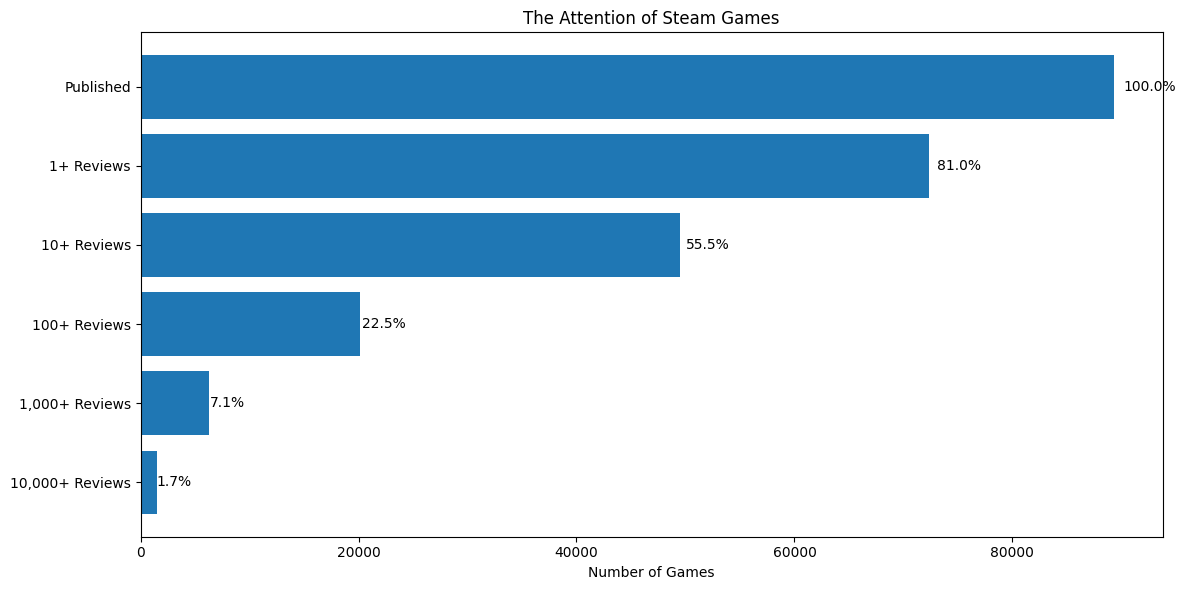

In [26]:
total_games = len(df)

stages = {
    "Published": total_games,
    "1+ Reviews": (df["num_reviews"] >= 1).sum(),
    "10+ Reviews": (df["num_reviews"] >= 10).sum(),
    "100+ Reviews": (df["num_reviews"] >= 100).sum(),
    "1,000+ Reviews": (df["num_reviews"] >= 1000).sum(),
    "10,000+ Reviews": (df["num_reviews"] >= 10000).sum(),
}

funnel = pd.DataFrame(list(stages.items()), columns=["Stage", "Games"])
funnel["Percent"] = funnel["Games"] / funnel.iloc[0]["Games"] * 100

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(funnel["Stage"], funnel["Games"])
ax.invert_yaxis()
for bar, pct in zip(bars, funnel["Percent"]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2, f"{pct:.1f}%", va="center",)

ax.set_title("The Attention of Steam Games")
ax.set_xlabel("Number of Games")

plt.tight_layout()
plt.show()

#### Do games reach the same levels of visibility each year?
The multi-line chart captures the trend of attention levels over the year.<br>
The following graph is an evolution of the previous one, showing that the games have more and more difficulty in capturing the player's attention. The percentage of games with over 10000 reviews stay a steady top 1%, the rest of them slowly decreases, saying that the general public's opinion concentrates on the few selected games, while the rest of them have increasing difficulty getting noticed. 

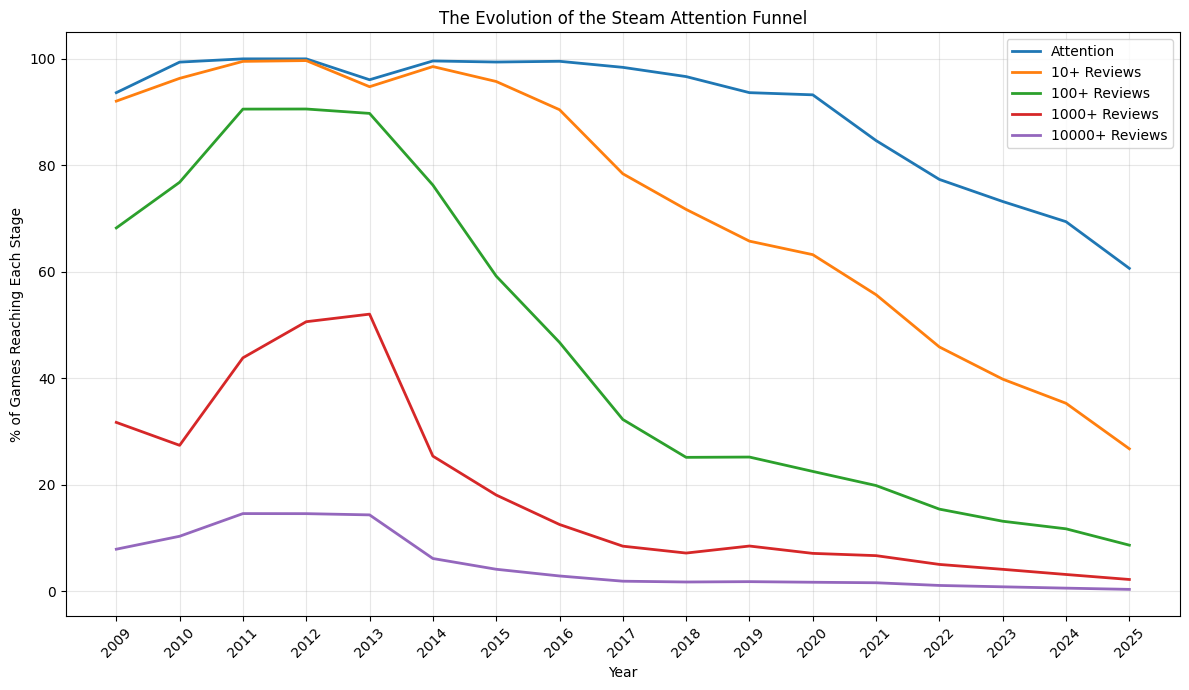

In [27]:
# Redefine the "dead" condition and calculate the funnel metrics by year
dead = ((df["num_reviews"] == 0) & (df["peak_ccu"] == 0) & (df["avg_playtime"] == 0))
years = sorted(df["year"].dropna().unique())
records = []

for year in years:
    subset = df[df["year"] == year]
    total = len(subset)

    # Skip years with too few games to avoid noise in the percentages
    # As shown in the previous plots, the early years have very few games and could skew the percentages
    if total < 20:  
        continue

    records.append({
            "year": year,
            # Attention defines the percentage of games that have at least some attention (not dead)
            "Attention": ((~dead.loc[subset.index]).sum() / total) * 100,
            "10+ Reviews": ((subset["num_reviews"] >= 10).sum() / total) * 100,
            "100+ Reviews": ((subset["num_reviews"] >= 100).sum() / total) * 100,
            "1000+ Reviews": ((subset["num_reviews"] >= 1000).sum() / total) * 100,
            "10000+ Reviews": ((subset["num_reviews"] >= 10000).sum() / total) * 100,
        })

funnel_year = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(12, 7))

for col in [
    "Attention",
    "10+ Reviews",
    "100+ Reviews",
    "1000+ Reviews",
    "10000+ Reviews",
]:
    ax.plot(funnel_year["year"], funnel_year[col], linewidth=2, label=col)

ax.set_title("The Evolution of the Steam Attention Funnel")
ax.set_xlabel("Year")
ax.set_ylabel("% of Games Reaching Each Stage")
ax.legend()

plt.grid(alpha=0.3)
plt.xticks(funnel_year["year"], rotation=45)
plt.tight_layout()
plt.show()

#### Final consideration
A few games stand out in the constant growth of the gaming market, holding the majority of the 'wealth' leaving the others a more scarse visibility. From the number of reviews point of view, it means, at least that many people has ever played that game, confirming the high skewness of the industry's attention distribution. 

### F2P vs Paying games
F2P stands for Free-To-Play, are the games with 0 economic commitment, thus, free games. While the 0-price is an atticing offer, not all free games are on the same level, some are more liked than the others, and even more so the paying games. The assumption is that a person would pay for something because they like the object in question, and so they tends to leave a positive feedback. This should remain true for the gaming market.<br>
The following grouped bar chart shows the difference between the in "popularity" metrics, the mean peak_ccu and mean number of reviews per game, divided into the two categories.<br><br>

The results show that F2P games have a much higher audience both in terms of peak_ccu and number of reviews with respect to paying games. But paying games are much more liked, shown by the mean percentage of positive reviews.

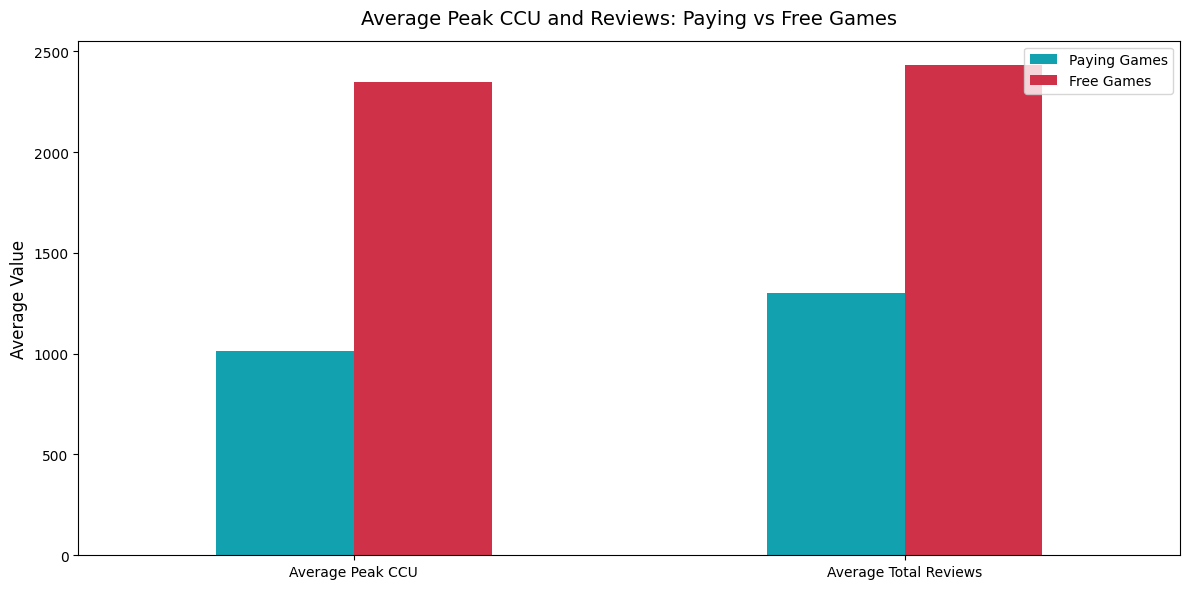

In [28]:
paying = df[df['full_price'] > 0].copy()
free = df[df['full_price'] == 0].copy()

mean_ccu_paying = paying['peak_ccu'].mean()
mean_ccu_free = free['peak_ccu'].mean()

mean_reviews_paying = paying['num_reviews'].mean()
mean_reviews_free = free['num_reviews'].mean()

data = pd.DataFrame({
    'Paying Games': [mean_ccu_paying, mean_reviews_paying],
    'Free Games': [mean_ccu_free, mean_reviews_free]
}, index=['Average Peak CCU', 'Average Total Reviews']
)

data.plot(kind='bar', figsize=(12, 6), color=["#12A1AE", "#CF3149"])
plt.title('Average Peak CCU and Reviews: Paying vs Free Games', fontsize=14, pad=12)
plt.ylabel('Average Value', fontsize=12)
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

A separate bar chart shows better the difference in the mean percentage of positive reviews between the two categories, because the scale issue. 

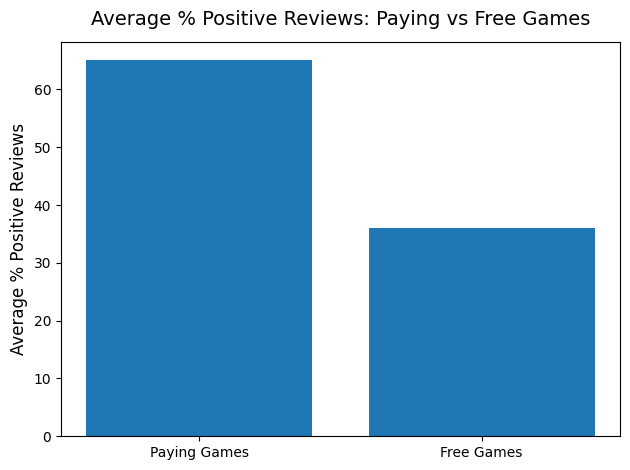

In [29]:
mean_pos_reviews_paying = paying['pct_pos_reviews'].mean().astype(int)
mean_pos_reviews_free = free['pct_pos_reviews'].mean().astype(int)

x = ['Paying Games', 'Free Games']
data_pos = [mean_pos_reviews_paying, mean_pos_reviews_free]

plt.bar(x, data_pos)
plt.title('Average % Positive Reviews: Paying vs Free Games', fontsize=14, pad=12)
plt.ylabel('Average % Positive Reviews', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

A further investigation into F2P shows that the majority of its entries have 0 positive reviews. A more precise analysis should be made excluding "dead games".<br><br>
The same charts are plotted with addition of the alive free games to show how much the "dead games" influence the distribution, further confirming that more games means more dilluted attention for each game.<br>
In addition, this shows that price is one of the main factor in a player's gaming choice

Free games - Mode of % positive reviews: 0%, Median of % positive reviews: 0.0%


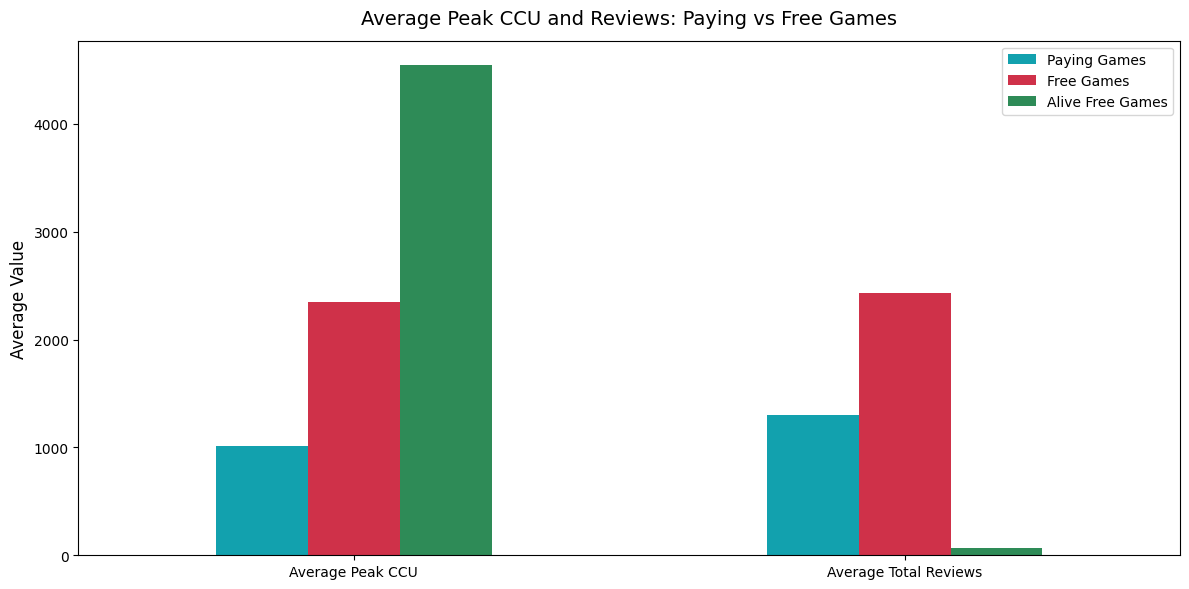

In [30]:
# Compute mode and median for % positive reviews for paying and free games
mode_free, median_free = free['pct_pos_reviews'].mode()[0], free['pct_pos_reviews'].median()
print(f"Free games - Mode of % positive reviews: {mode_free}%, Median of % positive reviews: {median_free}%")

# Filter out the dead free games
free_alive = free[~free['id'].isin(three_zeros['id'])]

mean_ccu_free_alive = free_alive['peak_ccu'].mean()
mean_reviews_free_alive = free_alive['pct_pos_reviews'].mean()

data = pd.DataFrame({
    'Paying Games': [mean_ccu_paying, mean_reviews_paying],
    'Free Games': [mean_ccu_free, mean_reviews_free],
    'Alive Free Games': [mean_ccu_free_alive, mean_reviews_free_alive]
}, index=['Average Peak CCU', 'Average Total Reviews']
)

data.plot(kind='bar', figsize=(12, 6), color=["#12A1AE", "#CF3149", "#2E8B57"])
plt.title('Average Peak CCU and Reviews: Paying vs Free Games', fontsize=14, pad=12)
plt.ylabel('Average Value', fontsize=12)
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

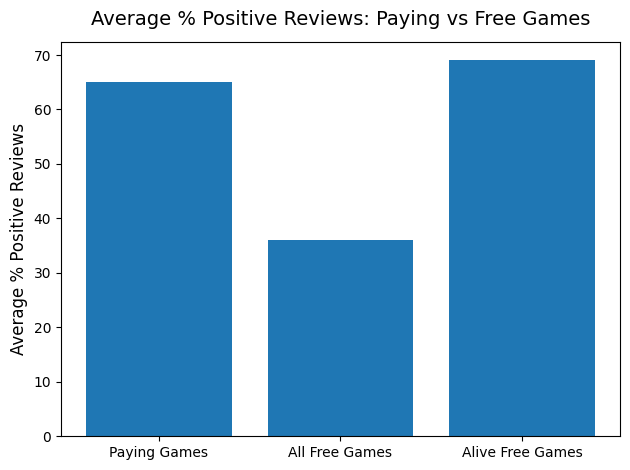

In [31]:
mean_pos_reviews_free_alive = free_alive['pct_pos_reviews'].mean().astype(int)

x = ['Paying Games', 'All Free Games', 'Alive Free Games']
data_pos = [mean_pos_reviews_paying, mean_pos_reviews_free, mean_pos_reviews_free_alive]

plt.bar(x, data_pos)
plt.title('Average % Positive Reviews: Paying vs Free Games', fontsize=14, pad=12)
plt.ylabel('Average % Positive Reviews', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### How does price change the game reputation?
We have already established that free games receives lower positive reputation and the dead games influence negatively the market. But how does the price actually influence a game's reputation.<br>
The following analysis divides the games into different ranges and trace the change in its reputation as the price increases.<br><br>

Interestingly, the line chart shows that even with the price of 1 euro, the reputation jumps from 35% to ~57%, and its approval stablize in rage 15-50 around 70%. But, when the price reaches over 60, its approval decreases, the assumption is that the game's aggressive pricing does not match the high expections.

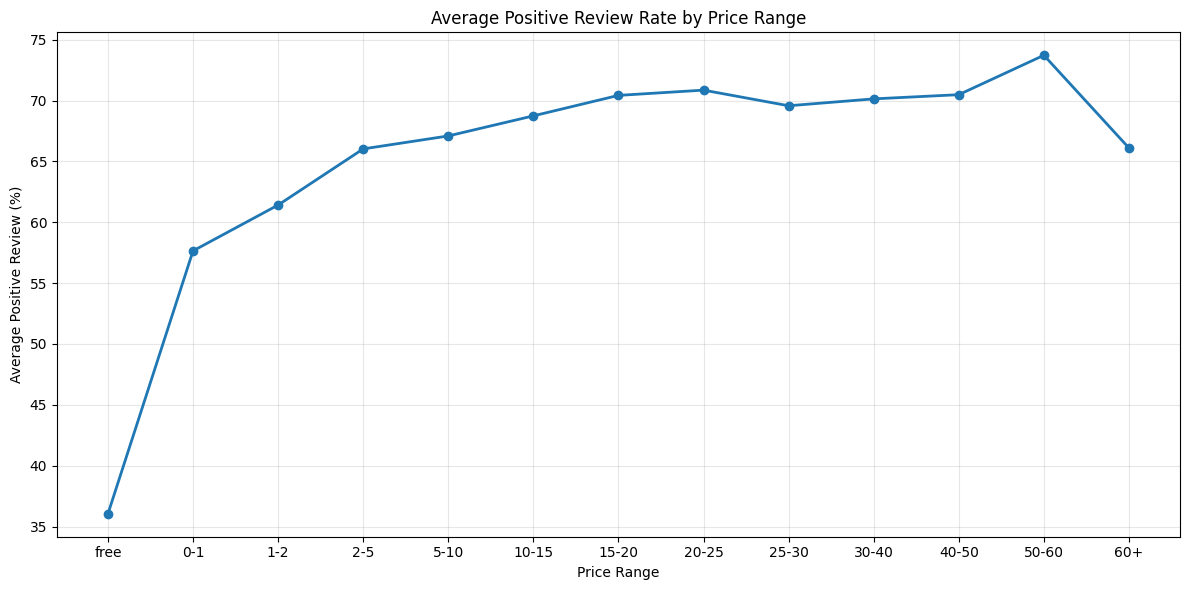

In [32]:
bins = [0, 0.1, 1, 2, 5, 10, 15, 20, 25, 30, 40, 50, 60, float("inf")]
labels = [
    "free",
    "0-1",
    "1-2",
    "2-5",
    "5-10",
    "10-15",
    "15-20",
    "20-25",
    "25-30",
    "30-40",
    "40-50",
    "50-60",
    "60+",
]


df["price_band"] = pd.cut(
    df["full_price"], bins=bins, labels=labels, right=False
)

reputation = (
    df.groupby("price_band", observed=True)
    .agg(avg_positive=("pct_pos_reviews", "mean"), games=("price_band", "size"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(reputation["price_band"], reputation["avg_positive"], marker="o", linewidth=2)
ax.set_title("Average Positive Review Rate by Price Range")
ax.set_xlabel("Price Range")
ax.set_ylabel("Average Positive Review (%)")

plt.xticks(rotation=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Final consideration
The F2P is among the most played category, thanks to the 0 economic commitment, but the vast number of games influence negatively their reputation, and that only a few games stand out. Paying games has, in general, a better reputation, however, because the economic restraint, they may not reach the same number of audience as th F2P. Furthermore, a publisher should price their games accordingly, a higher price usually gathers higher expectation

### Public vs Critic
Another interesting data is the *metacritic_score*, only a very selected subset out of 90000 games has this value differ from 0. These games represent the more "pushed" ones by the publisher, they have been dedicated more resources to get promoted, and one way to do so, is to get reviewed and rated by the game critics. However, critics are still a collective of people with subjective opinion, they do not represent the public opinion; thus it is not unusual that the public opinion differs from the critic's. <br>
We will use *metacritic_score* to represent the critic's rating and once again, the *number of positive reviews* for the public opinion. We will also use average playtime as support metric.<br>
The **first plot** shows the distribution in absolute number of each bin along side the average playtime per bin. The **second plot** instead shows the average numbber of reviews (in logarithmic scale to show better the bins with lower values) along side the average percentage of positibe reviews.<br><br>

Both charts show that the public opinion actually goes along with the critic's rating. The more well rated games have more attention from the players and have better public reputation, measured using the percentage of positive reviews. <br>
In particular, there is a jump between the bin "85-90" and "90-100" in terms of average playtime

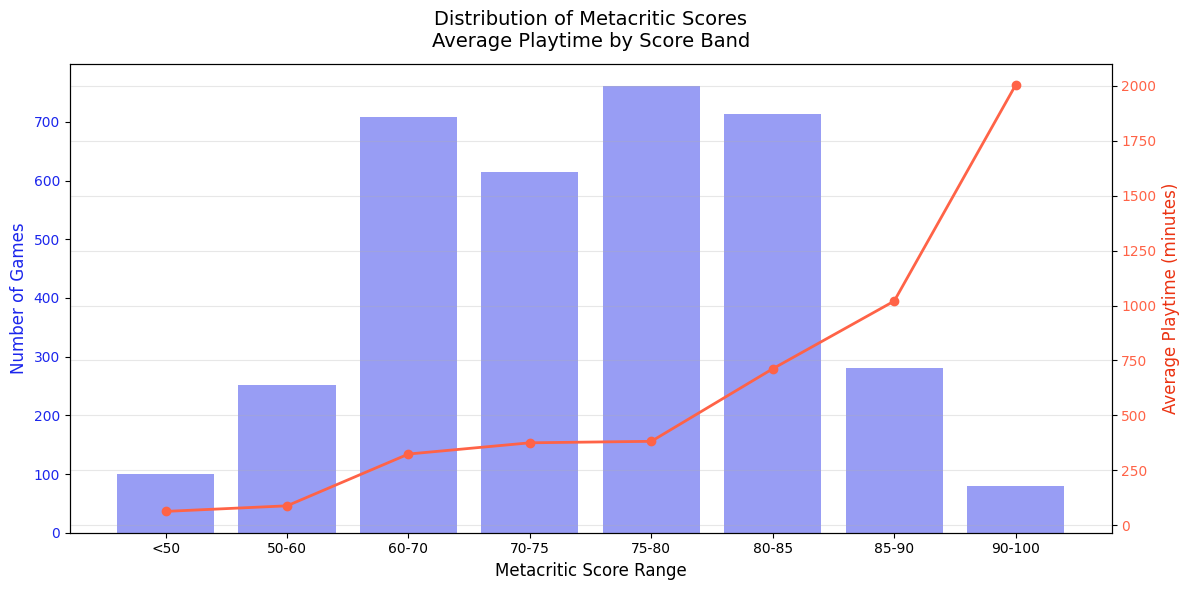

In [33]:
rated = df[(df["metacritic_score"] > 0) & (df["num_reviews"] > 0)].copy()

# Show the percentiles of the Metacritic scores to understand the distribution and decide on bins
scores = rated["metacritic_score"]
# print(scores.quantile([0.1, 0.25, 0.5, 0.75, 0.9]))

# Define bins and labels for Metacritic scores based on the distribution
bins = [0, 50, 60, 70, 75, 80, 85, 90, 100]
labels = ["<50", "50-60", "60-70", "70-75", "75-80", "80-85", "85-90", "90-100"]
rated["score_band"] = pd.cut(
    rated["metacritic_score"], bins=bins, labels=labels, right=False
)
score_dist = rated["score_band"].value_counts().sort_index()

# Calculate average playtime for each score band
avg_playtime_by_score = (
    rated.groupby(("score_band"), observed=True)["avg_playtime"].mean().reindex(labels)
)

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the distribution of Metacritic scores as bars on the primary y-axis
ax1.bar(score_dist.index, score_dist.values, color="#333ceb", alpha=0.5)
ax1.set_xlabel("Metacritic Score Range", fontsize=12)
ax1.set_ylabel("Number of Games", fontsize=12, color="#1c26ec")
ax1.tick_params(axis="y", labelcolor="#1c26ec")

# Plot the average playtime as a line on the secondary y-axis
ax2 = ax1.twinx()
ax2.plot(
    avg_playtime_by_score.index,
    avg_playtime_by_score.values,
    marker="o",
    color="#ff6347",
    linewidth=2,
)
ax2.set_ylabel("Average Playtime (minutes)", fontsize=12, color="#eb3211")
ax2.tick_params(axis="y", labelcolor="#ff6347")

ax1.set_title(
    "Distribution of Metacritic Scores\nAverage Playtime by Score Band",
    fontsize=14,
    pad=12,
)
plt.grid(alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

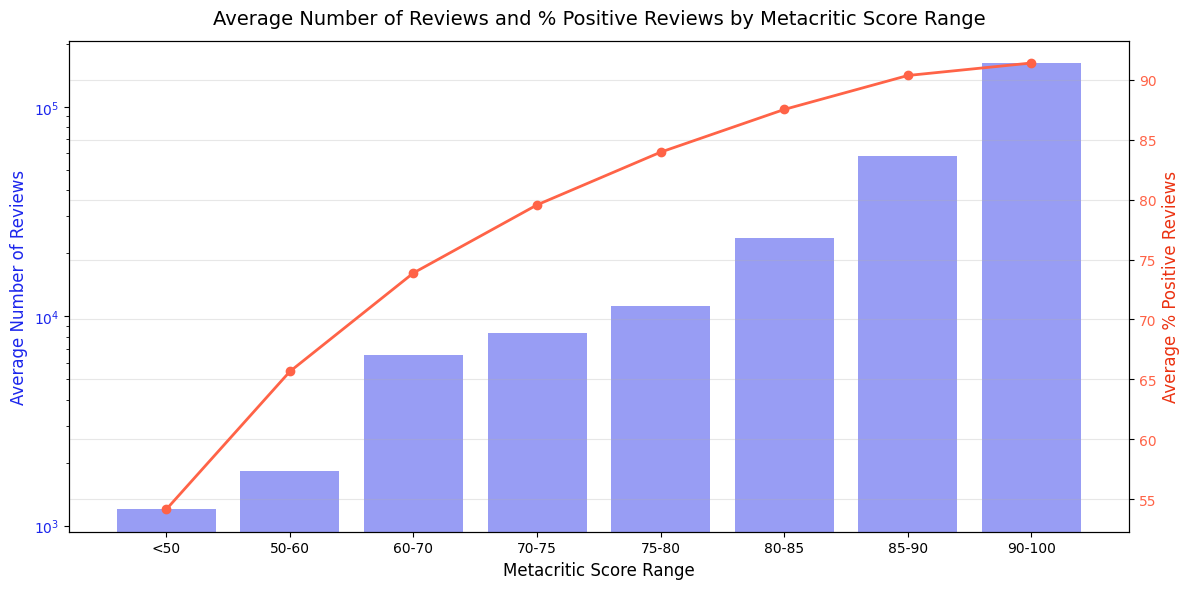

In [34]:
avg_num_reviews_by_score = (
    rated.groupby(("score_band"), observed=True)["num_reviews"].mean().reindex(labels)
)

avg_pct_pos_by_score = (
    rated.groupby(("score_band"), observed=True)["pct_pos_reviews"]
    .mean()
    .reindex(labels)
)

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot average number of reviews as bars on the primary y-axis
plt.yscale("log")  # Use logarithmic scale for better visibility of differences
ax1.bar(
    avg_num_reviews_by_score.index,
    avg_num_reviews_by_score.values,
    color="#333ceb",
    alpha=0.5,
)
ax1.set_xlabel("Metacritic Score Range", fontsize=12)
ax1.set_ylabel("Average Number of Reviews", fontsize=12, color="#1c26ec")
ax1.tick_params(axis="y", labelcolor="#1c26ec")

# Plot average % positive reviews as a line on the secondary y-axis
ax2 = ax1.twinx()
ax2.plot(
    avg_pct_pos_by_score.index,
    avg_pct_pos_by_score.values,
    marker="o",
    color="#ff6347",
    linewidth=2,
)
ax2.set_ylabel("Average % Positive Reviews", fontsize=12, color="#eb3211")
ax2.tick_params(axis="y", labelcolor="#ff6347")

ax1.set_title(
    "Average Number of Reviews and % Positive Reviews by Metacritic Score Range",
    fontsize=14,
    pad=12,
)
plt.grid(alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Deeper analysis
On the surface, the public opinion agrees with the critic's rating, or at least, this is true for the majority of rated games. However, a simple correlation computed between metacritic_score and pct_pos_reviews results in 0.599, meaning that the two actually agrees 60% of the time, and the 40% of time, their opinions differ.<br>

In [35]:
"""
Calculate the correlation between Metacritic score and % positive reviews
The resulting correlation coefficient will indicate the strength and direction of the linear relationship between these two variables
The calculated 54% correlation suggests a moderate positive relationship
meaning that as the Metacritic score increases, the percentage of positive reviews tends to increase as well
This implies that 46% of times, the Metacritic score does not align with the percentage of positive reviews
"""

corr_score_pos = rated[["metacritic_score", "pct_pos_reviews"]].corr().iloc[0, 1]
print(
    f"Correlation between Metacritic score and % positive reviews: {corr_score_pos:.3f}"
)

Correlation between Metacritic score and % positive reviews: 0.599


A scatter plot of data points in rated subset. The graphic shows where a game sits in the agree/disagree-ment between public opinion and critic's score. The diagonal line shows the perfect aggrement between the critic's score and public opinion<br>
The resulting graph is bearly visible due to high number of datapoint

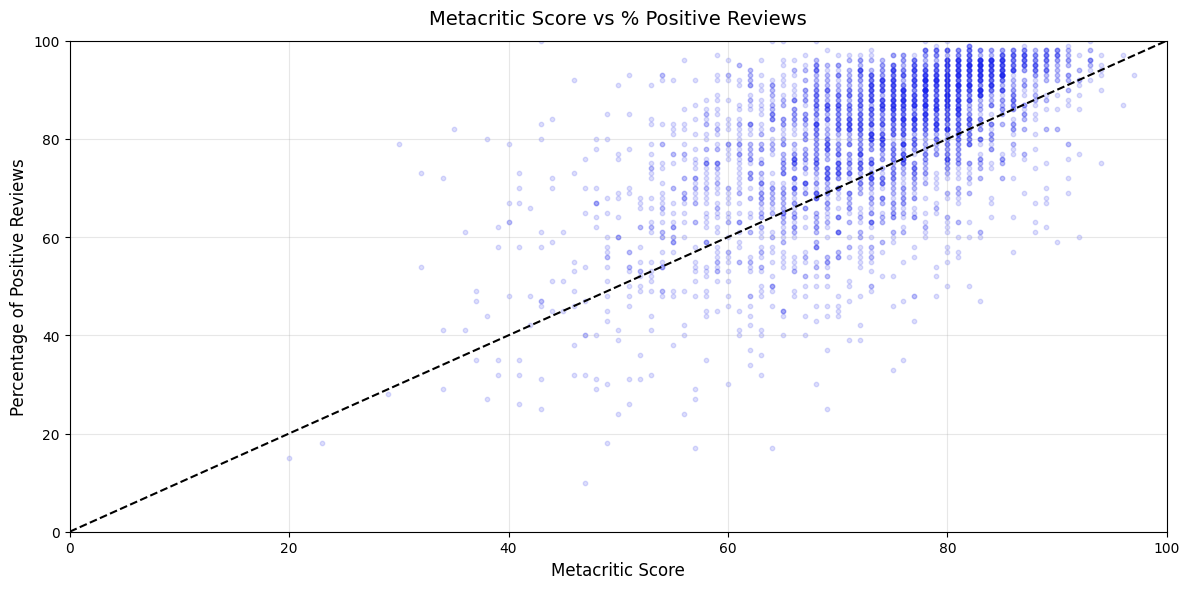

In [36]:
ax = rated.plot.scatter(
    x="metacritic_score",
    y="pct_pos_reviews",
    alpha=0.15,
    s=10,
    figsize=(12, 6),
    color="#1c26ec",
)
ax.set_xlabel("Metacritic Score", fontsize=12)
ax.set_ylabel("Percentage of Positive Reviews", fontsize=12)
ax.set_title("Metacritic Score vs % Positive Reviews", fontsize=14, pad=12)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.plot([0,100],[0,100], '--', color='black')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The following hexbin plot serves the same function as the previous scatter plot, in addition, it shows the 'population' density. The same diagonal line serves as perfect aggrement between the public and critic.<br>
Here, we can see clearer the agree/disagree-ment of a game because it uses density representation instead of single data points.<br><br>

With the help of the diagonal line, the perfect aggrement, we can describe the agree/disagree-ment into the graphic. The upper part represents a better public opinion while the lower part represents a better critic's rating. Further a game is away from the line, the larger is the difference in the rating between the two parties. 

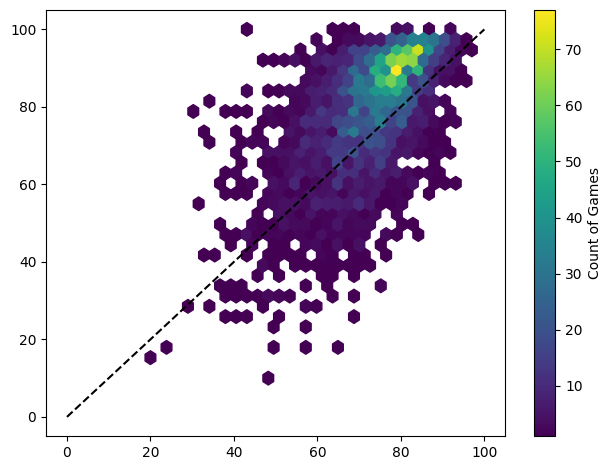

In [37]:
ax = plt.hexbin(
    rated["metacritic_score"],
    rated["pct_pos_reviews"],
    gridsize=30,
    cmap="viridis",
    mincnt=1,
)
plt.plot([0,100],[0,100], '--', color='black')

plt.colorbar(label="Count of Games")
plt.tight_layout()
plt.show()

#### To what degree the public and critic agree on a game's rating
The following hexbin plot is a further "evolution", showing the distribution of the datapoints, the density distribution, and the color represents the degree of agree/disagree-ment in absolute value. *Green* shows the agreement, *Yellow and Orange* shows slight disagreement, *Red* shows the strongly disagreement. By analysing the position in which a data is found, we know immediately if the datapoint is loved by the public and hated by the critic or the other way around. <br><br>

The resulting graph shows the majority of the games' rating are agreed by both critic and public, some of them are less so. There are some very bright red dots.

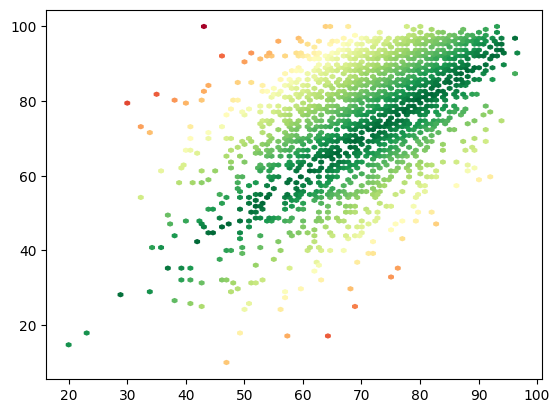

In [38]:
# Calculate the absolute difference between Metacritic score and % positive reviews to visualize the agreement/disagreement
agreement = abs(
    rated['pct_pos_reviews'] - rated['metacritic_score']
)
plt.hexbin(
    rated['metacritic_score'],
    rated['pct_pos_reviews'],
    # Param. C accumuates the values to be visualized in the hexagonal bins, by default it accumulates the number of occurrence
    # but we can use the absolute difference to visualize the agreement/disagreement
    C=agreement, 
    reduce_C_function=np.mean,
    cmap='RdYlGn_r'
)

#### Who are the most disagreed titles?
We would like to put a name to the data, and the following shows games that public loved but critic disagreed, and viceversa. A positive value shows that public's opinion is higher than the critic's; a negative value means that public disagrees with critic's rating. 

C:\Users\zhuji\AppData\Local\Temp\ipykernel_5364\796308250.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rated["agreement"] = rated["pct_pos_reviews"] - rated["metacritic_score"]


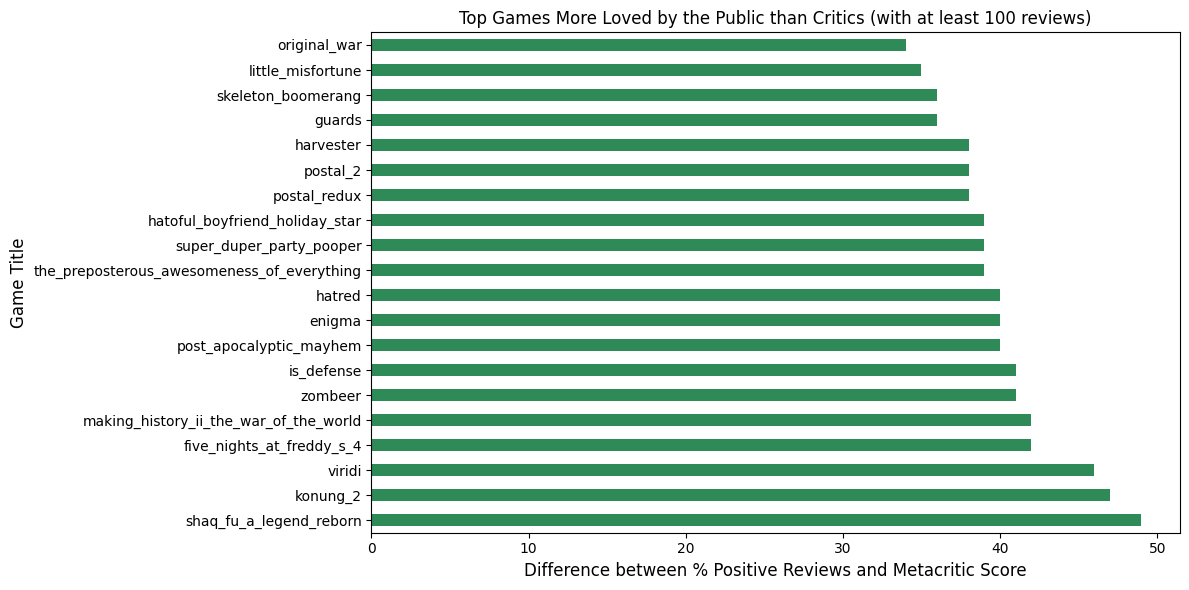

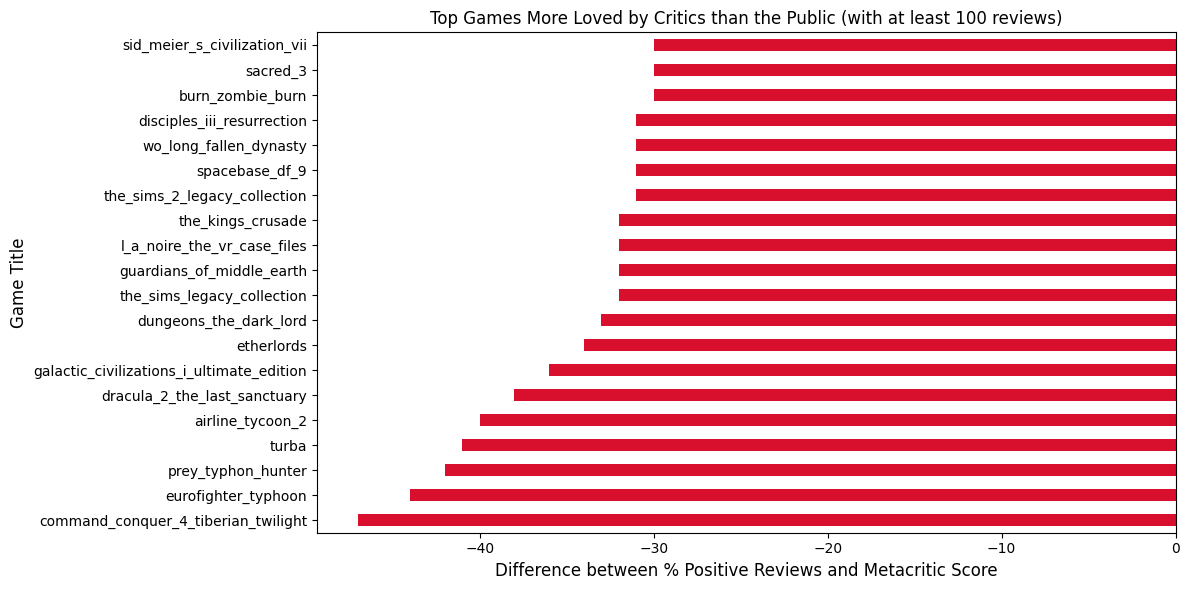

In [39]:
# A quick check shows that some of the games in the top 20 lists have very few reviews
# which could make their position less representative of a general public/critic consensus
# There are around 22% of games with more than 100 reviews, we can filter the dataset to this threshold
rated = rated[rated["num_reviews"] >= 100]

rated["agreement"] = rated["pct_pos_reviews"] - rated["metacritic_score"]

public_favourite = (rated.sort_values("agreement", ascending=False).head(20))
critic_favourite = (rated.sort_values("agreement", ascending=True).head(20))

ax = public_favourite.plot.barh(
    x="name",
    y="agreement",
    color="#2E8B57",
    figsize=(12, 6),
    legend=False,
    title="Top Games More Loved by the Public than Critics (with at least 100 reviews)",
)
ax.set_xlabel("Difference between % Positive Reviews and Metacritic Score", fontsize=12)
ax.set_ylabel("Game Title", fontsize=12)
plt.tight_layout()
plt.show()

ax1 = critic_favourite.plot.barh(
    x="name",
    y="agreement",
    color="#D8102E",
    figsize=(12, 6),
    legend=False,
    title="Top Games More Loved by Critics than the Public (with at least 100 reviews)",
)
ax1.set_xlabel("Difference between % Positive Reviews and Metacritic Score", fontsize=12)
ax1.set_ylabel("Game Title", fontsize=12)
plt.tight_layout()
plt.show()

The following highlights outliers in the original scatter plot, whose size is scaled according to the total number of reviews to show the game popularity among the players

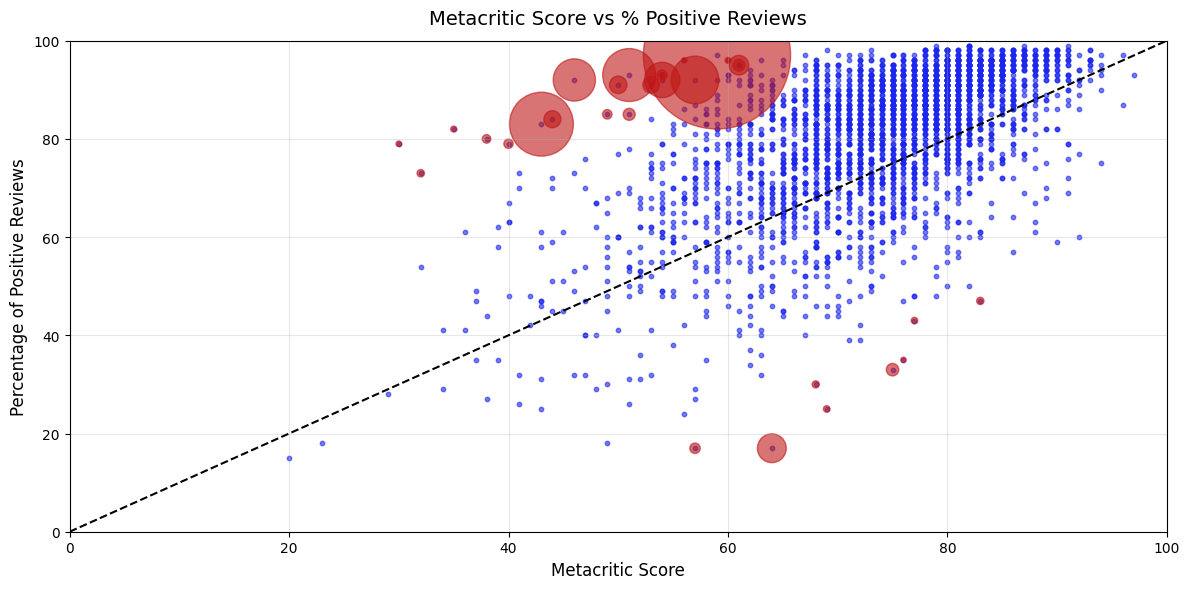

In [40]:
top_outliers = rated.loc[rated['agreement'].abs().sort_values(ascending=False).head(30).index].copy()

ax = rated.plot.scatter(
    x="metacritic_score",
    y="pct_pos_reviews",
    alpha=0.6,
    s=10,
    figsize=(12, 6),
    color="#1c26ec",
)

plt.scatter(
    top_outliers["metacritic_score"],
    top_outliers["pct_pos_reviews"],
    s=top_outliers["num_reviews"] / 10,  # Scale down for better visibility
    alpha=0.6,
    color="#BF17174D",
)

ax.set_xlabel("Metacritic Score", fontsize=12)
ax.set_ylabel("Percentage of Positive Reviews", fontsize=12)
ax.set_title("Metacritic Score vs % Positive Reviews", fontsize=14, pad=12)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.plot([0,100],[0,100], '--', color='black')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### What makes these games are more liked by the public?
What are the reasons why the public likes these game when the public hated them.<br>
A stacked bar chart shows the top 40 most liked games by the public but the critic disagrees, while highlighting the indie genre.<br><br>

The results show that most of the top 40 games are of the indie genre, and their price range is within 5-20 euros. This claims that the public prefers indie games that has a low cost.

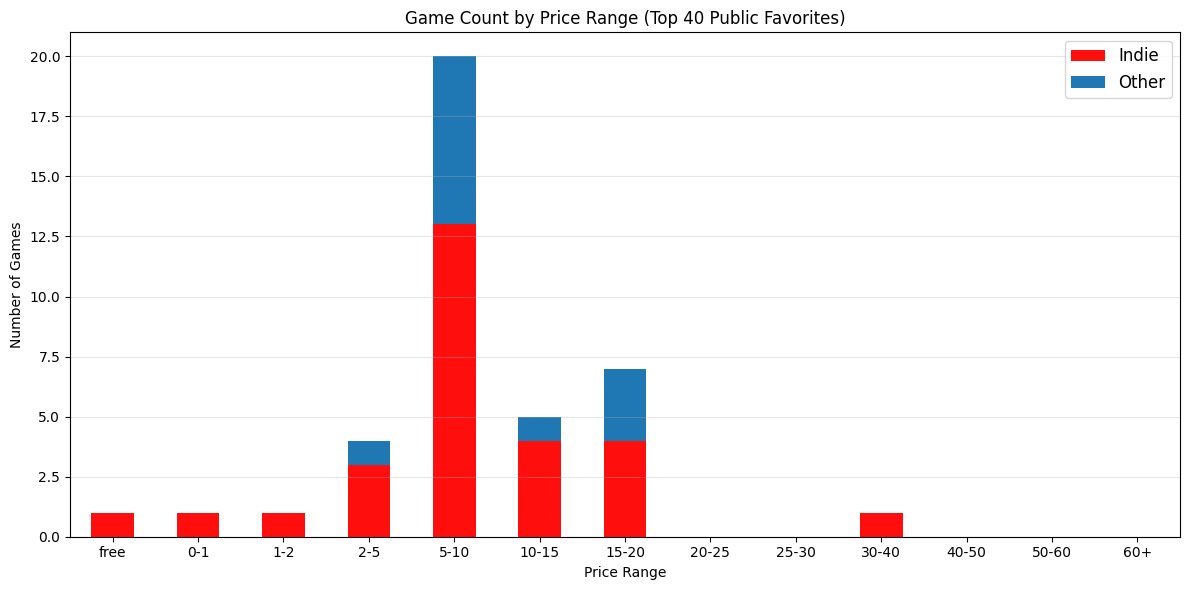

In [41]:
indie_mask = rated[rated['tags'].copy().apply(has_indie)]
public_favourite_indie = rated[rated['id'].isin(indie_mask['id']) & (rated['agreement'] > 0)].sort_values('agreement', ascending=False)

public_favourite = rated[rated["agreement"] > 0].sort_values(
    "agreement", ascending=False
)
top40 = public_favourite.head(40)

# Count total games and indie games by price band
total_counts = top40['price_band'].value_counts().sort_index()
indie_counts = top40[top40['id'].isin(indie_mask['id'])]['price_band'].value_counts().sort_index()

# Align indices and fill missing values
indie_counts = indie_counts.reindex(total_counts.index, fill_value=0)
other_counts = total_counts - indie_counts

# Create stacked bar chart
plot_data = pd.DataFrame({
    'Indie': indie_counts,
    'Other': other_counts
})

fig, ax = plt.subplots(figsize=(12, 6))
plot_data.plot(kind='bar', stacked=True, ax=ax, color=['#ff0e0e', '#1f77b4'])

ax.set_title("Game Count by Price Range (Top 40 Public Favorites)")
ax.set_xlabel("Price Range")
ax.set_ylabel("Number of Games")
ax.legend(loc='upper right', fontsize=12)

plt.xticks(rotation=0)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

#### Final remark
The general player base agrees with the critic's rating on the majority of titles. The genral trend is that the better rated game usually receives more attention from the players, who in turn, judge the game by leaving a positive/negative review.
The outliers exist, those games whose rating differs from the player and critic's point of views. A quick analysis shows that the general public likes indie games of low economic commitment, however the critics disagree.